# SSL Anomaly Detection - Exploratory Data Analysis

**Purpose**: Merge certificate and label data, perform EDA, and test statistical significance of features for phishing detection.

**Data Sources**:
- Live certs: `data/raw/certs_live.jsonl` (data_source: "argon_live")
- Live labels: `data/raw/labels_live.jsonl` (PhishTank + Tranco + Unknown)
- Historical phishing certs: `data/raw/certs_phishing_historical.jsonl` (data_source: "crtsh_historical")

In [43]:
import json
import math
import warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from Levenshtein import distance as levenshtein
import tldextract

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

In [44]:
# Helper function for effect size calculation
def cohens_d(group1, group2):
    """Calculate Cohen's d for effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 == 0 or n2 == 0:
        return 0
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0

## 1. Load and Merge Data

### Load Live Data (argon_live)

In [45]:
# Load live certificates
df_live_certs = pd.read_json("../sources/raw/certs_live.jsonl", lines=True)

print(f"Loaded {len(df_live_certs):,} live cert records")
print(f"Data source: {df_live_certs['data_source'].unique()}")
print(f"Date range: {pd.to_datetime(df_live_certs['timestamp']).min()} to {pd.to_datetime(df_live_certs['timestamp']).max()}")

# Explode domains (one row per domain)
df_live_domains = (df_live_certs
    .explode("domains")
    .rename(columns={"domains": "domain"})
    .dropna(subset=["domain"])
)
df_live_domains["domain"] = df_live_domains["domain"].str.lower().str.strip().str.lstrip("*.")
df_live_domains = df_live_domains[df_live_domains["domain"].str.len() > 0]

print(f"Exploded to {len(df_live_domains):,} domain records")
print(f"Unique domains: {df_live_domains['domain'].nunique():,}")

Loaded 8,569 live cert records
Data source: <ArrowStringArray>
['argon_live']
Length: 1, dtype: str
Date range: 2026-04-30 16:40:40.327884+00:00 to 2026-04-30 17:55:56.760861+00:00
Exploded to 18,963 domain records
Unique domains: 13,362


In [46]:
# Load live labels
df_live_labels = pd.read_json("../sources/raw/labels_live.jsonl", lines=True)

print(f"\nLoaded {len(df_live_labels):,} live labels")
print(f"Label breakdown:")
print(df_live_labels['label_source'].value_counts())

# Merge certs with labels
df_live = df_live_domains.merge(
    df_live_labels[["domain", "y", "label_source"]],
    on="domain",
    how="left"
)

# Reallocate "unknown" label sources to "phishtank" for clarity
df_live['label_source'] = df_live['label_source'].replace({'unknown': 'phishtank'})

# Confirm changes
df_live.head()



Loaded 13,362 live labels
Label breakdown:
label_source
unknown    13361
tranco         1
Name: count, dtype: int64


,schema_version,timestamp,cert_index,fingerprint,serial,not_before,not_after,domain,subject,issuer,source,data_source,y,label_source
0,1,2026-04-30 16:40:40.327884+00:00,2774052981,28:9B:23:35:83:D0:DA:EB:4D:4D:8F:FF:B7:E3:E4:8...,4.095516e+37,1777563414,1777649813,1777567014225739345-11qh5rlo6snuy.tls-alpn-01....,"{'CN': None, 'O': None, 'C': None}","{'CN': 'WR1', 'O': 'Google Trust Services', 'C...","{'name': 'Google 'Argon2026h1' log', 'url': 'h...",argon_live,0,phishtank
1,1,2026-04-30 16:40:40.329318+00:00,2774052982,0F:4A:D7:CD:23:7B:F6:6C:8E:5D:EE:D1:1A:0F:6C:F...,5.623912e+18,1777567098,1780245471,pay.sheliamiller.com,"{'CN': 'pay.sheliamiller.com', 'O': None, 'C':...",{'CN': 'Go Daddy Secure Certificate Authority ...,"{'name': 'Google 'Argon2026h1' log', 'url': 'h...",argon_live,0,phishtank
2,1,2026-04-30 16:40:40.329318+00:00,2774052982,0F:4A:D7:CD:23:7B:F6:6C:8E:5D:EE:D1:1A:0F:6C:F...,5.623912e+18,1777567098,1780245471,www.pay.sheliamiller.com,"{'CN': 'pay.sheliamiller.com', 'O': None, 'C':...",{'CN': 'Go Daddy Secure Certificate Authority ...,"{'name': 'Google 'Argon2026h1' log', 'url': 'h...",argon_live,0,phishtank
3,1,2026-04-30 16:40:40.329753+00:00,2774052985,3A:5B:FB:48:A5:A2:C4:96:8E:B0:74:6F:D9:D1:64:0...,2.652525e+36,1777567101,1777653472,ext.ais.dev.claitdev.com,"{'CN': 'imperva.com', 'O': None, 'C': None}",{'CN': 'GlobalSign Atlas R3 DV TLS CA 2026 Q2'...,"{'name': 'Google 'Argon2026h1' log', 'url': 'h...",argon_live,0,phishtank
4,1,2026-04-30 16:40:40.329753+00:00,2774052985,3A:5B:FB:48:A5:A2:C4:96:8E:B0:74:6F:D9:D1:64:0...,2.652525e+36,1777567101,1777653472,imperva.com,"{'CN': 'imperva.com', 'O': None, 'C': None}",{'CN': 'GlobalSign Atlas R3 DV TLS CA 2026 Q2'...,"{'name': 'Google 'Argon2026h1' log', 'url': 'h...",argon_live,0,phishtank


### Load Historical Phishing Data (crtsh_historical)

In [47]:
# Check if historical data exists
hist_file = Path("../sources/raw/certs_phishing_historical.jsonl")

if hist_file.exists():
    # Load historical phishing certificates
    df_hist_certs = pd.read_json(hist_file, lines=True)
    
    print(f"Loaded {len(df_hist_certs):,} historical phishing cert records")
    print(f"Data source: {df_hist_certs['data_source'].unique()}")
    
    # Explode domains
    df_hist_domains = (df_hist_certs
        .explode("domains")
        .rename(columns={"domains": "domain"})
        .dropna(subset=["domain"])
    )
    df_hist_domains["domain"] = df_hist_domains["domain"].str.lower().str.strip()
    df_hist_domains = df_hist_domains[df_hist_domains["domain"].str.len() > 0]
    
    # Historical data is already labeled (y=1 from PhishTank)
    if "y" not in df_hist_domains.columns:
        df_hist_domains["y"] = 1
        df_hist_domains["label_source"] = "phishtank"
    
    print(f"Exploded to {len(df_hist_domains):,} domain records")
    print(f"Unique domains: {df_hist_domains['domain'].nunique():,}")
    
    # Create df_hist for consistency
    df_hist = df_hist_domains.copy()
else:
    print("No historical data file found - skipping")
    df_hist = pd.DataFrame()  # Empty dataframe

# Wouldn't see fingerprint or cert_index from crt.sh, drop
df_hist = df_hist.drop(columns=["fingerprint", "cert_index"], errors="ignore")

Loaded 6,836 historical phishing cert records
Data source: <ArrowStringArray>
['crtsh_historical']
Length: 1, dtype: str
Exploded to 11,158 domain records
Unique domains: 4,389


In [48]:
# print(df_hist.groupby("y")["not_before"].apply(lambda x: x.isna()).sum())
df_hist['y'].value_counts()

y
1    11158
Name: count, dtype: int64

In [49]:
df_hist = df_hist[df_hist["not_before"].notna() & df_hist["not_after"].notna()].reset_index(drop=True)
df_hist['domain'].nunique()

2816

In [50]:
df_hist.info()

<class 'pandas.DataFrame'>
RangeIndex: 7360 entries, 0 to 7359
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   schema_version   7360 non-null   int64              
 1   timestamp        7360 non-null   datetime64[us, UTC]
 2   serial           7360 non-null   str                
 3   not_before       7360 non-null   float64            
 4   not_after        7360 non-null   float64            
 5   domain           7360 non-null   str                
 6   subject          7360 non-null   object             
 7   issuer           7360 non-null   object             
 8   source           7360 non-null   object             
 9   data_source      7360 non-null   str                
 10  phishing_domain  7360 non-null   str                
 11  label_source     7360 non-null   str                
 12  label_ts         7360 non-null   str                
 13  y                7360 non-nul

## 2. Exploratory Data Analysis - SSL Cert Attributes

### 2.1 Dataset Overview

In [51]:
# Summary statistics
print("="*80)
print("LIVE DATA SUMMARY (argon_live)")
print("="*80)
print(f"Total records: {len(df_live):,}")
print(f"Unique domains: {df_live['domain'].nunique():,}")
print(f"Unique certificates: {df_live['serial'].nunique():,}")
print(f"\nLabel distribution:")
print(df_live['y'].value_counts().rename({0: "Legitimate/Unknown", 1: "Phishing"}))
print(f"\nLabel sources:")
print(df_live['label_source'].value_counts())
print(f"\nPhishing rate: {df_live['y'].mean():.4%}")

if not df_hist.empty:
    print("\n" + "="*80)
    print("HISTORICAL DATA SUMMARY (crtsh_historical)")
    print("="*80)
    print(f"Total records: {len(df_hist):,}")
    print(f"Unique domains: {df_hist['domain'].nunique():,}")
    print(f"Unique certificates: {df_hist['serial'].nunique():,}")
    print(f"\nAll records are phishing (y=1): {(df_hist['y'] == 1).all()}")
    print(f"Label source: {df_hist['label_source'].unique()}")

LIVE DATA SUMMARY (argon_live)
Total records: 18,963
Unique domains: 13,362
Unique certificates: 7,773

Label distribution:
y
Legitimate/Unknown    18963
Name: count, dtype: int64

Label sources:
label_source
phishtank    18961
tranco           2
Name: count, dtype: int64

Phishing rate: 0.0000%

HISTORICAL DATA SUMMARY (crtsh_historical)
Total records: 7,360
Unique domains: 2,816
Unique certificates: 4,474

All records are phishing (y=1): True
Label source: <ArrowStringArray>
['phishtank']
Length: 1, dtype: str


### 2.2 Issuer Analysis

Top 10 Issuers for Phishing Domains (Live Data):
No phishing domains found in live data

Top 10 Issuers for Legitimate Domains (Live Data):
issuer_org
Amazon                   6930
Google Trust Services    5116
Microsoft Corporation    1670
GoDaddy.com, Inc.        1328
Let's Encrypt            1077
GlobalSign nv-sa         1070
DigiCert Inc              724
Sectigo Limited           442
DigiCert, Inc.            168
Certainly                 166
Name: count, dtype: int64

Let's Encrypt Usage by Label (Live Data)
is_letsencrypt     False     True 
y                                 
0               0.943205  0.056795


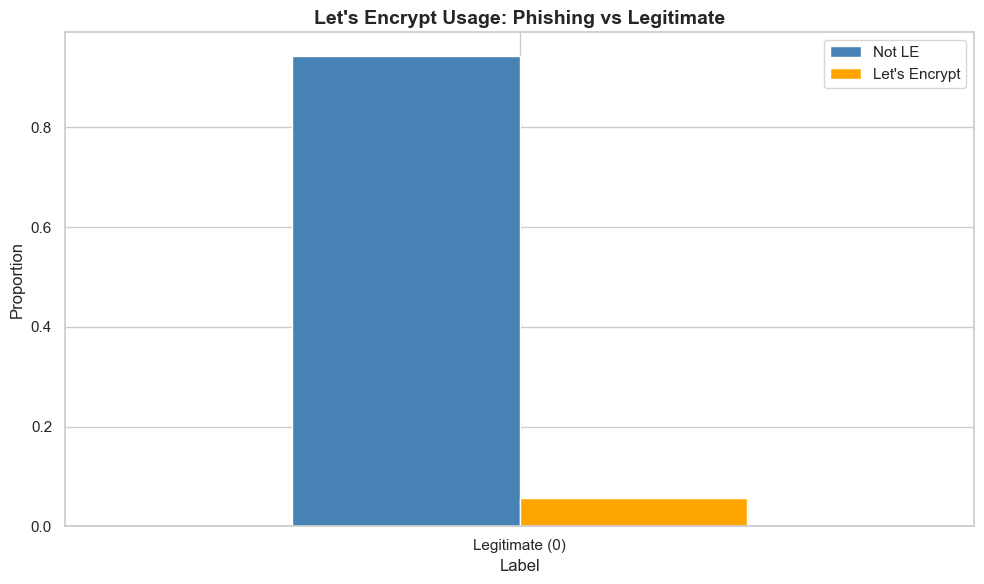

In [52]:
# Extract issuer organization
def extract_issuer_org(issuer):
    if isinstance(issuer, dict):
        return issuer.get('O', 'Unknown')
    return 'Unknown'

df_live['issuer_org'] = df_live['issuer'].apply(extract_issuer_org)

# Top issuers by label
print("Top 10 Issuers for Phishing Domains (Live Data):")
phishing_issuers = df_live[df_live['y'] == 1]['issuer_org'].value_counts().head(10)
if len(phishing_issuers) > 0:
    print(phishing_issuers)
else:
    print("No phishing domains found in live data")

print("\nTop 10 Issuers for Legitimate Domains (Live Data):")
print(df_live[df_live['y'] == 0]['issuer_org'].value_counts().head(10))

# Let's Encrypt usage
df_live['is_letsencrypt'] = df_live['issuer_org'].str.contains("Let's Encrypt", na=False, case=False)

print("\n" + "="*60)
print("Let's Encrypt Usage by Label (Live Data)")
print("="*60)
le_by_label = df_live.groupby('y')['is_letsencrypt'].value_counts(normalize=True).unstack()
print(le_by_label)

# Only plot if we have data for both classes or at least one class
if len(le_by_label) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    le_by_label.plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
    ax.set_title("Let's Encrypt Usage: Phishing vs Legitimate", fontsize=14, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Proportion')
    # Use dynamic labels based on actual indices
    label_names = {0: 'Legitimate (0)', 1: 'Phishing (1)'}
    ax.set_xticklabels([label_names[idx] for idx in le_by_label.index], rotation=0)
    ax.legend(['Not LE', "Let's Encrypt"])
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot Let's Encrypt usage")

Top 10 Issuers for Phishing Domains (Live Data):
issuer_org
Let's Encrypt              4834
Google Trust Services      1023
Sectigo Limited             837
ZeroSSL                     192
SSL Corporation             124
"GoDaddy.com                 91
Amazon                       78
DigiCert Inc                 48
"TrustAsia Technologies      30
ZeroSSL GmbH                 18
Name: count, dtype: int64

Let's Encrypt Usage by Label (Live Data)
is_letsencrypt     False     True 
y                                 
1               0.343207  0.656793


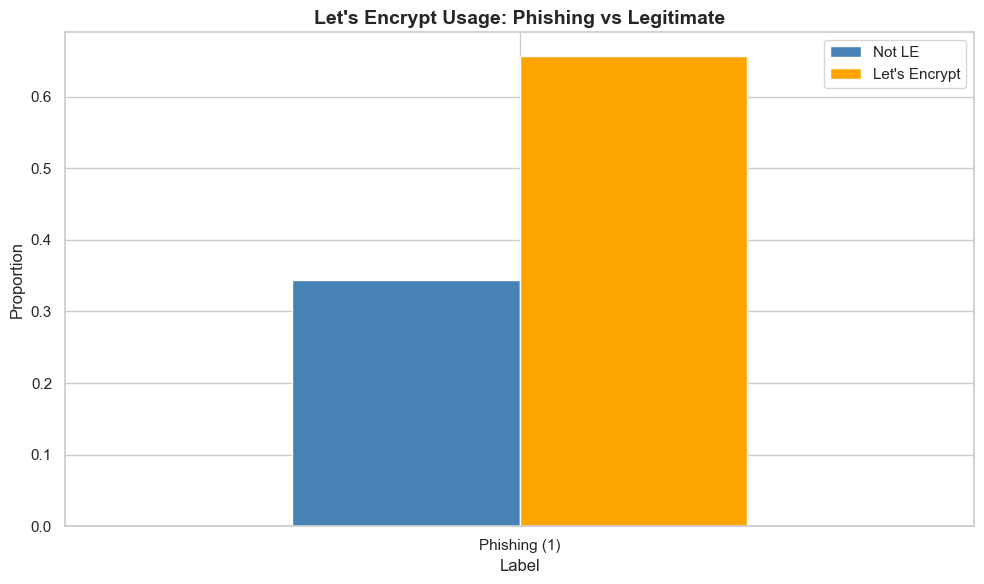

In [53]:
df_hist['issuer_org'] = df_hist['issuer'].apply(extract_issuer_org)

# Top issuers by label
print("Top 10 Issuers for Phishing Domains (Live Data):")
phishing_issuers = df_hist[df_hist['y'] == 1]['issuer_org'].value_counts().head(10)
if len(phishing_issuers) > 0:
    print(phishing_issuers)
else:
    print("No phishing domains found in live data")

# Let's Encrypt usage
df_hist['is_letsencrypt'] = df_hist['issuer_org'].str.contains("Let's Encrypt", na=False, case=False)

print("\n" + "="*60)
print("Let's Encrypt Usage by Label (Live Data)")
print("="*60)
le_by_label = df_hist.groupby('y')['is_letsencrypt'].value_counts(normalize=True).unstack()
print(le_by_label)

# Only plot if we have data for both classes or at least one class
if len(le_by_label) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    le_by_label.plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
    ax.set_title("Let's Encrypt Usage: Phishing vs Legitimate", fontsize=14, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Proportion')
    # Use dynamic labels based on actual indices
    label_names = {0: 'Legitimate (0)', 1: 'Phishing (1)'}
    ax.set_xticklabels([label_names[idx] for idx in le_by_label.index], rotation=0)
    ax.legend(['Not LE', "Let's Encrypt"])
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot Let's Encrypt usage")

### 2.4 Wildcard Analysis

In [54]:
def is_wildcard(domains) -> int:
    if not domains:
        return 0
    return int(any(d.startswith("*.") for d in domains))

Wildcard by Label (Live Data)
is_wildcard    0
y               
0            1.0


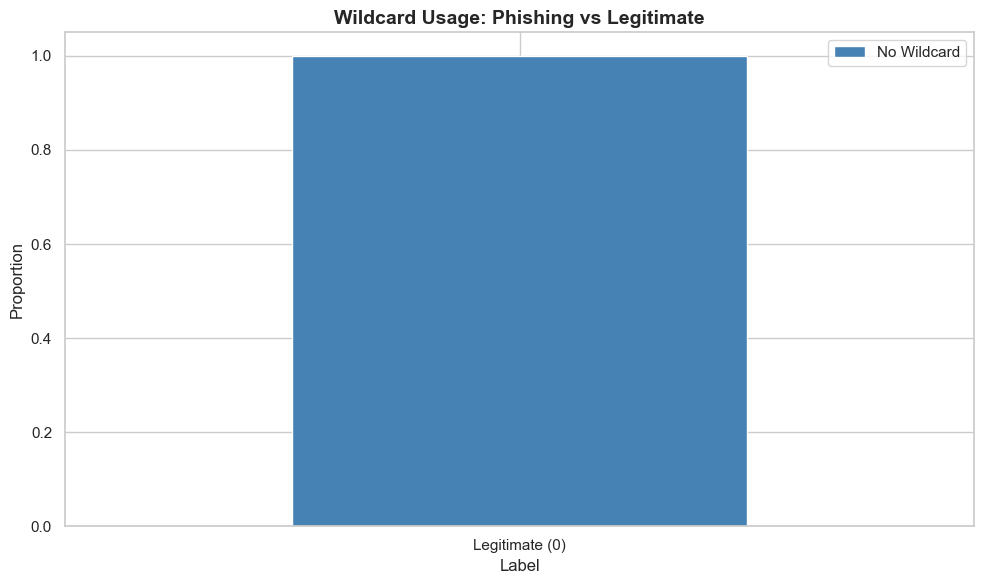

In [55]:
df_live['is_wildcard'] = df_live['domain'].apply(is_wildcard)

print("Wildcard by Label (Live Data)")
print("="*60)
le_by_label = df_live.groupby('y')['is_wildcard'].value_counts(normalize=True).unstack()
print(le_by_label)

# Only plot if we have data for both classes or at least one class
if len(le_by_label) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    le_by_label.plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
    ax.set_title("Wildcard Usage: Phishing vs Legitimate", fontsize=14, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Proportion')
    # Use dynamic labels based on actual indices
    label_names = {0: 'Legitimate (0)', 1: 'Phishing (1)'}
    ax.set_xticklabels([label_names[idx] for idx in le_by_label.index], rotation=0)
    ax.legend(['No Wildcard', "Wildcard"])
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot Wildcard usage")

Wildcard by Label (Historical Phishing Data)
has_wildcard     False     True 
y                               
1             0.741848  0.258152


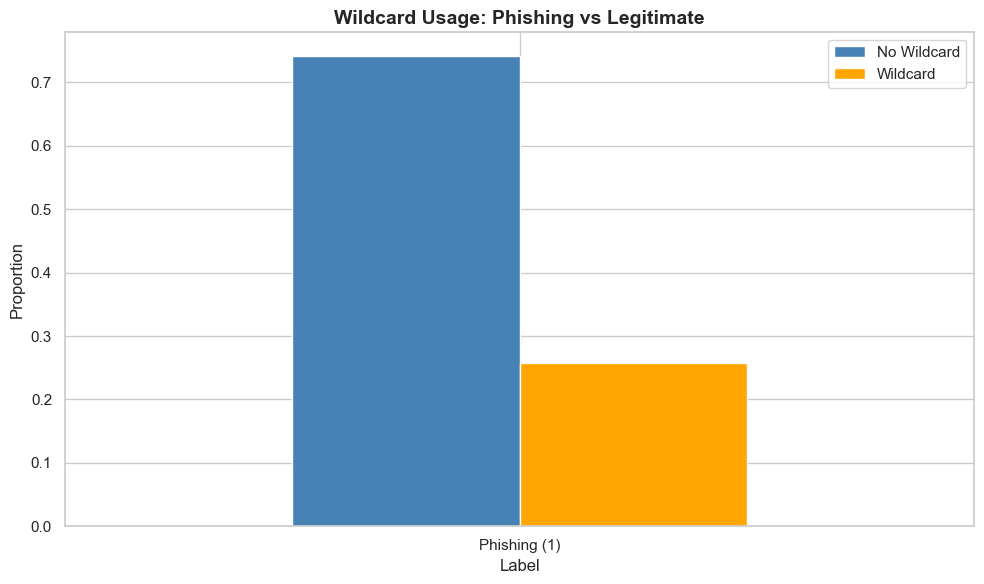

In [56]:
df_hist["has_wildcard"] = df_hist["domain"].str.contains(r"^\*\.", regex=True)

print("Wildcard by Label (Historical Phishing Data)")
print("="*60)
le_by_label = df_hist.groupby('y')['has_wildcard'].value_counts(normalize=True).unstack()
print(le_by_label)

# Only plot if we have data for both classes or at least one class
if len(le_by_label) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    le_by_label.plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
    ax.set_title("Wildcard Usage: Phishing vs Legitimate", fontsize=14, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Proportion')
    # Use dynamic labels based on actual indices
    label_names = {0: 'Legitimate (0)', 1: 'Phishing (1)'}
    ax.set_xticklabels([label_names[idx] for idx in le_by_label.index], rotation=0)
    ax.legend(['No Wildcard', "Wildcard"])
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot Wildcard usage")

### 2.5 SAN Count Analysis

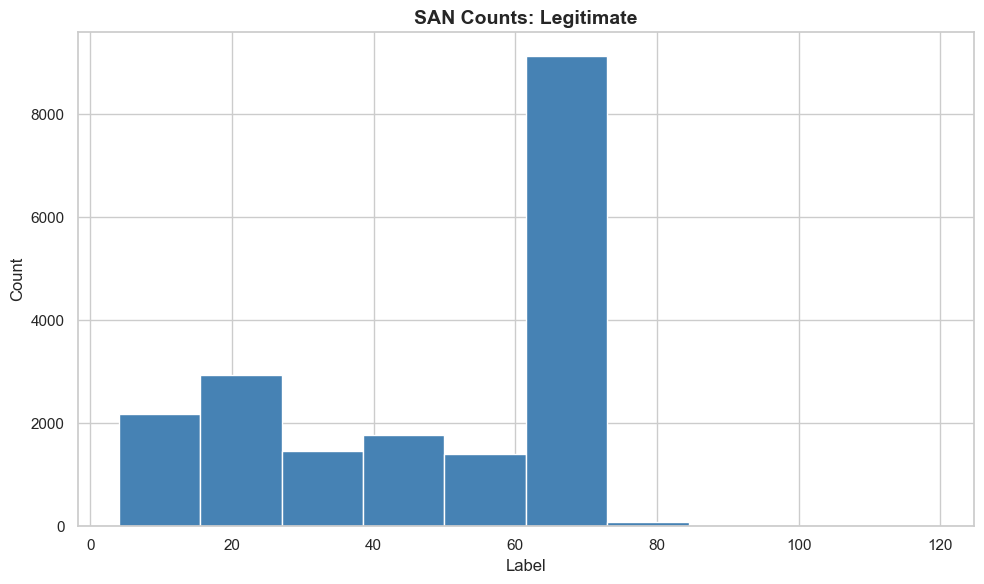

In [57]:
df_live['san_count'] = df_live['domain'].apply(len)

# Only plot if we have data for both classes or at least one class
if len(le_by_label) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    df_live['san_count'].plot(kind='hist', ax=ax, color=['steelblue', 'orange'])
    ax.set_title("SAN Counts: Legitimate", fontsize=14, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot Wildcard usage")

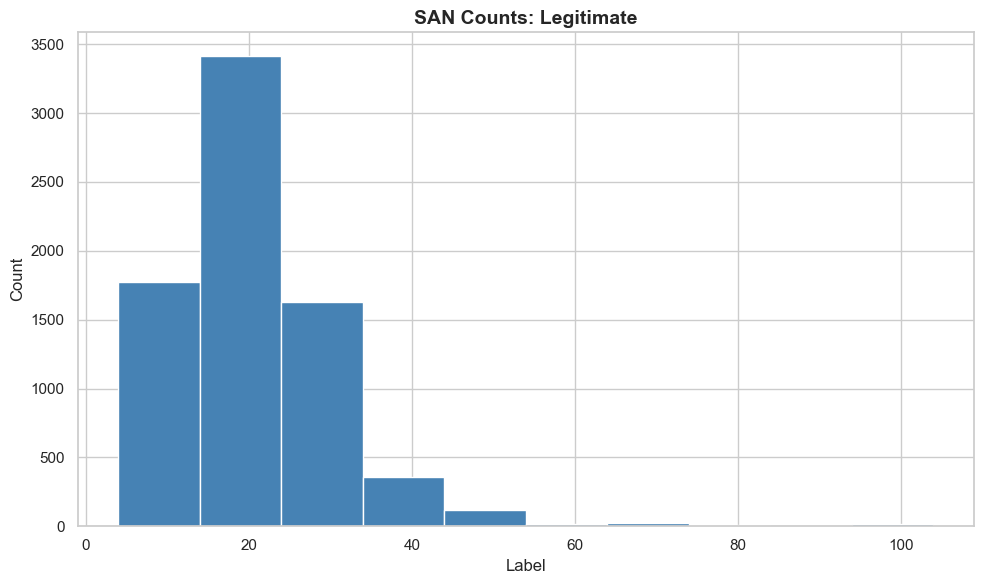

In [58]:
df_hist['san_count'] = df_hist['domain'].apply(len)

# Only plot if we have data for both classes or at least one class
if len(le_by_label) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    df_hist['san_count'].plot(kind='hist', ax=ax, color=['steelblue', 'orange'])
    ax.set_title("SAN Counts: Legitimate", fontsize=14, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot Wildcard usage")

### 2.6 Domain Mismatch Analysis

In [59]:
df_live["subject"].apply(lambda x: x.get("CN") if isinstance(x, dict) else None).isna().sum()

np.int64(2081)

In [60]:
import tldextract

def cn_san_mismatch(row):
    subject = row["subject"]
    if not isinstance(subject, dict):
        return 0
    cn = (subject.get("CN") or "").lower().lstrip("*.")
    if not cn:
        return 0
    domain = (row.get("domain") or "").lower().lstrip("*.")
    
    cn_base     = tldextract.extract(cn).registered_domain
    domain_base = tldextract.extract(domain).registered_domain
    
    if not cn_base or not domain_base:
        return 0
    return int(cn_base != domain_base)

In [61]:
import ast
df_live["cn_san_mismatch"] = df_live.apply(cn_san_mismatch, axis=1)

# fig, ax = plt.subplots(figsize=(8, 5))

df_live.groupby("y")["cn_san_mismatch"].mean()

y
0    0.022201
Name: cn_san_mismatch, dtype: float64

In [62]:
df_hist["cn_san_mismatch"] = df_hist.apply(cn_san_mismatch, axis=1)
df_hist.groupby("y")["cn_san_mismatch"].mean()

y
1    0.029484
Name: cn_san_mismatch, dtype: float64

## 3. Exploratory Data Analysis - Domain Attributes

### Domain entropy, domain length, subdomain count, tld, digit count, validity days

In [63]:
# Domain entropy
def domain_entropy(domain):
    s = domain.replace(".", "")
    if not s:
        return 0.0
    counts = Counter(s)
    total = len(s)
    return -sum((c / total) * math.log2(c / total) for c in counts.values())

# Subdomain count
def subdomain_count(domain):
    ext = tldextract.extract(domain)
    if not ext.subdomain:
        return 0
    return len(ext.subdomain.split("."))

In [64]:
# Domain length
df_live['domain_length'] = df_live['domain'].str.len()

# What's entropy again? 
df_live['entropy'] = df_live['domain'].str.lstrip("*.").apply(domain_entropy)

df_live['subdomain_count'] = df_live['domain'].apply(subdomain_count)

#What's tld again?
df_live['tld'] = df_live['domain'].apply(lambda d: tldextract.extract(d).suffix.lower())

df_live['digit_count'] = df_live['domain'].apply(lambda d: sum(c.isdigit() for c in d))

# Certificate validity duration (days), when 
df_live['validity_days'] = ((df_live['not_after'] - df_live['not_before']) / 86400).clip(lower=0, upper=3650)

# Certificate age
# df_live['age_days'] = ((df_live['timestamp'] - df_live['not_before']) / 86400).clip(lower=0)

print("Features engineered successfully")
print(f"\nFeature summary:")
print(df_live[['domain_length', 'entropy', 'subdomain_count', 'digit_count', 'validity_days']].describe())

Features engineered successfully

Feature summary:
       domain_length       entropy  subdomain_count   digit_count  \
count   18963.000000  18963.000000     18963.000000  18963.000000   
mean       46.185466      3.948971         3.578284      3.424880   
std        20.366131      0.492289         2.451045      6.771902   
min         4.000000      1.251629         0.000000      0.000000   
25%        25.000000      3.625000         1.000000      0.000000   
50%        56.000000      4.126763         3.000000      0.000000   
75%        63.000000      4.286108         6.000000      2.000000   
max       119.000000      4.857767         9.000000     32.000000   

       validity_days  
count   18963.000000  
mean       29.677006  
std        64.026002  
min         0.999306  
25%         6.666655  
50%         7.041667  
75%        30.000000  
max       397.000000  


In [65]:
# Domain length
df_hist['domain_length'] = df_hist['domain'].str.len()

# What's entropy again? 
df_hist['entropy'] = df_hist['domain'].str.lstrip("*.").apply(domain_entropy)

df_hist['subdomain_count'] = df_hist['domain'].apply(subdomain_count)

#What's tld again?
df_hist['tld'] = df_hist['domain'].apply(lambda d: tldextract.extract(d).suffix.lower())

df_hist['digit_count'] = df_hist['domain'].apply(lambda d: sum(c.isdigit() for c in d))

# Certificate validity duration (days), when 
df_hist['validity_days'] = ((df_hist['not_after'] - df_hist['not_before']) / 86400).clip(lower=0, upper=3650)

# Certificate age
# df_live['age_days'] = ((df_live['timestamp'] - df_live['not_before']) / 86400).clip(lower=0)

print("Features engineered successfully")
print(f"\nFeature summary:")
print(df_hist[['domain_length', 'entropy', 'subdomain_count', 'digit_count', 'validity_days']].describe())

Features engineered successfully

Feature summary:
       domain_length      entropy  subdomain_count  digit_count  validity_days
count    7360.000000  7360.000000      7360.000000  7360.000000    7360.000000
mean       20.347690     3.343473         0.820109     0.729076     102.081591
std         9.691429     0.414660         0.797794     2.289657      59.595993
min         4.000000     1.521928         0.000000     0.000000      44.920914
25%        14.000000     3.095795         0.000000     0.000000      89.999988
50%        19.000000     3.381620         1.000000     0.000000      89.999988
75%        25.000000     3.625000         1.000000     0.000000      90.040093
max       104.000000     4.807842         6.000000    26.000000    1095.999988


## 4. Comprehensive Feature Engineering (Test New Features)

Using the new `FeatureEngineer` class to extract ALL available features:
- **Certificate-level**: age, validity, wildcard, SANs, issuer org, subject org
- **Domain-level**: entropy, hyphens, digits, vowel/consonant ratio, consecutive consonants, brand distance, keywords
- **TLD risk**: high-risk TLD detection

**Goal**: Test all features and identify which ones are most discriminative for phishing detection.

In [66]:
# Import the comprehensive feature engineering module
import sys
sys.path.insert(0, '..')

from src.features.feature_engineering import FeatureEngineer

print("="*80)
print("COMPREHENSIVE FEATURE EXTRACTION")
print("="*80)

# Initialize feature engineer (no external API calls for now)
fe = FeatureEngineer(
    use_whois=False,      # Disable WHOIS (slow)
    use_abuseipdb=False,  # Disable AbuseIPDB (requires API key)
    use_greynoise=False   # Disable GreyNoise (requires API key)
)

# Extract features from LIVE data (already exploded)
print("\n1. Extracting comprehensive features from LIVE data...")
print(f"   Input: {len(df_live):,} domain records")

# Since df_live is already exploded, we don't need to explode again
df_live_all_features = fe.extract_features(df_live_certs, explode_domains=True, verbose=True)

# Merge with labels
df_live_all_features = df_live_all_features.merge(
    df_live_labels[["domain", "y", "label_source"]],
    on="domain",
    how="left"
)
df_live_all_features["y"] = df_live_all_features["y"].fillna(0).astype(int)
df_live_all_features["label_source"] = df_live_all_features["label_source"].fillna("unlabeled")

# Extract features from HISTORICAL phishing data
if not df_hist.empty:
    print(f"\n2. Extracting comprehensive features from HISTORICAL data...")
    print(f"   Input: {len(df_hist_certs):,} cert records")
    
    df_hist_all_features = fe.extract_features(df_hist_certs, explode_domains=True, verbose=True)
    
    # Add labels (all are phishing)
    if "y" not in df_hist_all_features.columns:
        df_hist_all_features["y"] = 1
        df_hist_all_features["label_source"] = "phishtank"
else:
    df_hist_all_features = pd.DataFrame()

print("\n✅ Feature extraction complete!")
print(f"   Live data: {len(df_live_all_features):,} rows")
if not df_hist_all_features.empty:
    print(f"   Historical data: {len(df_hist_all_features):,} rows")

# Get list of all numeric features
all_feature_cols = fe.get_feature_list()
print(f"\n   Total features: {len(all_feature_cols)}")
print(f"   Features: {all_feature_cols}")

COMPREHENSIVE FEATURE EXTRACTION

1. Extracting comprehensive features from LIVE data...
   Input: 18,963 domain records
Extracting features from 8,569 certificates...
  - Extracting certificate features...
  - Exploding domains (one row per domain)...
  - Extracting domain features...
✅ Feature extraction complete: 18,963 rows, 28 features

2. Extracting comprehensive features from HISTORICAL data...
   Input: 6,836 cert records
Extracting features from 6,836 certificates...
  - Extracting certificate features...
  - Exploding domains (one row per domain)...
  - Extracting domain features...
✅ Feature extraction complete: 11,158 rows, 28 features

✅ Feature extraction complete!
   Live data: 18,963 rows
   Historical data: 11,158 rows

   Total features: 22
   Features: ['domain_length', 'entropy', 'subdomain_count', 'hyphen_count', 'digit_count', 'digit_ratio', 'vowel_consonant_ratio', 'consecutive_consonants', 'has_at_symbol', 'has_ip_address', 'tld_risk', 'brand_distance', 'is_bran

### 4.1 Re-Extract Features with Corrected Code

**Bug Fix Applied:**
- The original feature extraction had a bug where `is_wildcard` and `san_count` were calculated AFTER domains were exploded
- This caused these features to always receive an empty list, resulting in all 0 values
- Fix: Extract certificate features BEFORE exploding domains (src/features/feature_engineering.py:571-575)

In [67]:
# Reload the corrected feature engineering module
import importlib
import sys

# Force reload of the module to pick up the bug fix
if 'src.features.feature_engineering' in sys.modules:
    importlib.reload(sys.modules['src.features.feature_engineering'])

from src.features.feature_engineering import FeatureEngineer

print("="*80)
print("RE-EXTRACTING FEATURES WITH CORRECTED CODE")
print("="*80)

# Initialize feature engineer
fe_corrected = FeatureEngineer(
    use_whois=False,
    use_abuseipdb=False,
    use_greynoise=False
)

# Re-extract features from LIVE data
print("\n1. Re-extracting features from LIVE data...")
df_live_features_corrected = fe_corrected.extract_features(df_live_certs, explode_domains=True, verbose=True)

# Merge with labels
df_live_features_corrected = df_live_features_corrected.merge(
    df_live_labels[["domain", "y", "label_source"]],
    on="domain",
    how="left"
)
df_live_features_corrected["y"] = df_live_features_corrected["y"].fillna(0).astype(int)
df_live_features_corrected["label_source"] = df_live_features_corrected["label_source"].fillna("unlabeled")

# Re-extract features from HISTORICAL data
if not df_hist.empty:
    print(f"\n2. Re-extracting features from HISTORICAL data...")
    df_hist_features_corrected = fe_corrected.extract_features(df_hist_certs, explode_domains=True, verbose=True)
    
    # Add labels
    if "y" not in df_hist_features_corrected.columns:
        df_hist_features_corrected["y"] = 1
        df_hist_features_corrected["label_source"] = "phishtank"
else:
    df_hist_features_corrected = pd.DataFrame()

print("\n✅ Feature re-extraction complete!")
print(f"   Live data: {len(df_live_features_corrected):,} rows")
if not df_hist_features_corrected.empty:
    print(f"   Historical data: {len(df_hist_features_corrected):,} rows")

# Verify the fix worked by checking distributions
print("\n" + "="*80)
print("VERIFYING FIX: Checking Previously-Zero Features")
print("="*80)

all_feature_cols_corrected = fe_corrected.get_feature_list()

for feature in ['is_wildcard', 'san_count', 'has_at_symbol', 'is_self_signed']:
    if feature in df_live_features_corrected.columns:
        print(f"\n{feature} (Live):")
        print(df_live_features_corrected[feature].value_counts().head())
        
    if feature in df_hist_features_corrected.columns:
        print(f"\n{feature} (Historical):")
        print(df_hist_features_corrected[feature].value_counts().head())

RE-EXTRACTING FEATURES WITH CORRECTED CODE

1. Re-extracting features from LIVE data...
Extracting features from 8,569 certificates...
  - Extracting certificate features...
  - Exploding domains (one row per domain)...
  - Extracting domain features...
✅ Feature extraction complete: 18,963 rows, 28 features

2. Re-extracting features from HISTORICAL data...
Extracting features from 6,836 certificates...
  - Extracting certificate features...
  - Exploding domains (one row per domain)...
  - Extracting domain features...
✅ Feature extraction complete: 11,158 rows, 28 features

✅ Feature re-extraction complete!
   Live data: 18,963 rows
   Historical data: 11,158 rows

VERIFYING FIX: Checking Previously-Zero Features

is_wildcard (Live):
is_wildcard
0    15894
1     3069
Name: count, dtype: int64

is_wildcard (Historical):
is_wildcard
1    5769
0    5389
Name: count, dtype: int64

san_count (Live):
san_count
100    6400
1      5653
2      4792
5       690
3       687
Name: count, dtype:

### 4.2 Re-Run Comprehensive Statistical Tests with Corrected Features

Now that we've fixed the feature extraction bug, let's re-run the comprehensive statistical tests to get accurate Cohen's d values for all features.

In [68]:
# # Re-run comprehensive statistical tests with corrected features
# if not df_hist_features_corrected.empty and len(df_live_features_corrected[df_live_features_corrected['y'] == 0]) > 0:
#     print("="*100)
#     print("CORRECTED COMPREHENSIVE FEATURE STATISTICAL TESTS: Historical Phishing vs Live Legitimate")
#     print("="*100)
    
#     # Run tests for ALL numeric features
#     comprehensive_results_corrected = []
    
#     for feature in all_feature_cols_corrected:
#         # Historical phishing
#         hist_phish = df_hist_features_corrected[feature].dropna() if feature in df_hist_features_corrected.columns else pd.Series([])
        
#         # Live legitimate
#         live_legit = df_live_features_corrected[df_live_features_corrected['y'] == 0][feature].dropna()
        
#         if len(hist_phish) > 0 and len(live_legit) > 0:
#             # Mann-Whitney U test
#             try:
#                 statistic, p_value = stats.mannwhitneyu(hist_phish, live_legit, alternative='two-sided')
                
#                 # Cohen's d (using function defined earlier)
#                 effect_size = cohens_d(hist_phish, live_legit)
                
#                 comprehensive_results_corrected.append({
#                     'Feature': feature,
#                     'Phish Mean': hist_phish.mean(),
#                     'Legit Mean': live_legit.mean(),
#                     'Difference': hist_phish.mean() - live_legit.mean(),
#                     'p-value': p_value,
#                     "Cohens_d": effect_size,
#                     'Significant': 'Yes' if p_value < 0.05 else 'No',
#                     'Effect Size': 'Large' if abs(effect_size) >= 0.8 else ('Medium' if abs(effect_size) >= 0.5 else 'Small')
#                 })
#             except Exception as e:
#                 print(f"   ⚠️  Error testing {feature}: {e}")
    
#     df_comprehensive_stats_corrected = pd.DataFrame(comprehensive_results_corrected)
    
#     # Sort by absolute effect size (most discriminative first)
#     df_comprehensive_stats_corrected = df_comprehensive_stats_corrected.sort_values(
#         by="Cohens_d", 
#         key=lambda x: abs(x),
#         ascending=False
#     )
    
#     print(f"\nTested {len(df_comprehensive_stats_corrected)} features")
#     print(f"Significant features (p < 0.05): {(df_comprehensive_stats_corrected['Significant'] == 'Yes').sum()}")
#     print(f"Large effect size (|d| ≥ 0.8): {(df_comprehensive_stats_corrected['Effect Size'] == 'Large').sum()}")
#     print(f"Medium effect size (0.5 ≤ |d| < 0.8): {(df_comprehensive_stats_corrected['Effect Size'] == 'Medium').sum()}")
    
#     print("\n" + "="*100)
#     print("TOP 10 MOST DISCRIMINATIVE FEATURES (by effect size)")
#     print("="*100)
#     print(df_comprehensive_stats_corrected.head(10).to_string(index=False))
    
#     print("\n" + "="*100)
#     print("BOTTOM 10 LEAST DISCRIMINATIVE FEATURES (by effect size)")
#     print("="*100)
#     print(df_comprehensive_stats_corrected.tail(10).to_string(index=False))
    
#     # Highlight the previously-broken features
#     print("\n" + "="*100)
#     print("CORRECTED FEATURES (Previously Had Cohen's d = 0.000)")
#     print("="*100)
#     for feature in ['is_wildcard', 'san_count', 'has_at_symbol', 'is_self_signed']:
#         row = df_comprehensive_stats_corrected[df_comprehensive_stats_corrected['Feature'] == feature]
#         if not row.empty:
#             d = row['Cohens_d'].values[0]
#             p = row['p-value'].values[0]
#             print(f"  {feature:30s} | d={d:7.3f} | p={p:.2e} | {row['Effect Size'].values[0]}")
    
# else:
#     print("⚠️  Cannot run comprehensive feature tests - need both historical and live data")
#     df_comprehensive_stats_corrected = pd.DataFrame()

### 4.3 Categorical Analysis: SSL Certificate vs Domain Features

Separate analysis to understand which category of features is more discriminative:

**SSL Certificate Features** (infrastructure-level signals):
- `is_letsencrypt`: Issued by Let's Encrypt
- `is_wildcard`: Certificate uses wildcard (*.example.com)
- `san_count`: Number of Subject Alternative Names
- `cn_san_mismatch`: CN doesn't match SAN domain
- `has_subject_org`: Has Organization field (OV/EV cert indicator)
- `is_self_signed`: Self-signed certificate
- `validity_days`: Certificate validity period
- `cert_age_days`: Certificate age

**Domain Features** (domain-level signals):
- `domain_length`: Length of domain name
- `entropy`: Domain randomness (Shannon entropy)
- `subdomain_count`: Number of subdomain levels
- `tld_risk`: TLD risk score (0=trust, 1=neutral, 2=high-risk)
- `digit_count`: Number of digits in domain
- `digit_ratio`: Ratio of digits to total characters
- `hyphen_count`: Number of hyphens
- `vowel_consonant_ratio`: Vowel to consonant ratio
- `consecutive_consonants`: Max consecutive consonants
- `brand_distance`: Levenshtein distance to known brands
- `is_brand_lookalike`: Distance ≤ 3 to any brand
- `keyword_count`: Count of phishing keywords
- `has_keyword`: Contains phishing keyword

In [69]:
# Define feature categories
ssl_cert_features = [
    'is_letsencrypt', 
    'is_wildcard', 
    'san_count', 
    'cn_san_mismatch',
    'has_subject_org', 
    'is_self_signed', 
    'validity_days', 
    'cert_age_days'
]

domain_features = [
    'domain_length', 
    'entropy', 
    'subdomain_count', 
    'tld_risk',
    'digit_count', 
    'digit_ratio', 
    'hyphen_count',
    'vowel_consonant_ratio', 
    'consecutive_consonants',
    'brand_distance', 
    'is_brand_lookalike',
    'keyword_count', 
    'has_keyword',
    'has_at_symbol',
    'has_ip_address'
]

print("="*100)
print("CATEGORICAL FEATURE ANALYSIS: SSL Certificate vs Domain Features")
print("="*100)

# Prepare data for both categories
# We'll use the corrected features if available, otherwise fall back to original
if 'df_hist_features_corrected' in globals() and not df_hist_features_corrected.empty:
    hist_data = df_hist_features_corrected
    live_data = df_live_features_corrected
    print("\nUsing CORRECTED feature data")
elif 'df_hist_all_features' in globals() and not df_hist_all_features.empty:
    hist_data = df_hist_all_features
    live_data = df_live_all_features
    print("\nUsing ORIGINAL feature data")
else:
    hist_data = df_hist
    live_data = df_live
    print("\nUsing MANUAL feature data")

print(f"Historical phishing: {len(hist_data):,} records")
print(f"Live legitimate: {len(live_data[live_data['y'] == 0]):,} records")

# Function to run categorical analysis
def analyze_feature_category(features, category_name, hist_df, live_df):
    """Run statistical tests for a category of features."""
    results = []
    
    print(f"\n{'='*100}")
    print(f"{category_name.upper()} FEATURES ANALYSIS")
    print(f"{'='*100}")
    
    for feature in features:
        # Check if feature exists in both dataframes
        if feature not in hist_df.columns or feature not in live_df.columns:
            print(f"  ⚠️  Skipping {feature} (not found in data)")
            continue
            
        # Historical phishing
        hist_phish = hist_df[feature].dropna()
        
        # Live legitimate
        live_legit = live_df[live_df['y'] == 0][feature].dropna()
        
        if len(hist_phish) > 0 and len(live_legit) > 0:
            try:
                # Mann-Whitney U test
                statistic, p_value = stats.mannwhitneyu(hist_phish, live_legit, alternative='two-sided')
                
                # Cohen's d
                effect_size = cohens_d(hist_phish, live_legit)
                
                results.append({
                    'Feature': feature,
                    'Category': category_name,
                    'Phish Mean': hist_phish.mean(),
                    'Phish Std': hist_phish.std(),
                    'Legit Mean': live_legit.mean(),
                    'Legit Std': live_legit.std(),
                    'Difference': hist_phish.mean() - live_legit.mean(),
                    'p-value': p_value,
                    'Cohens_d': effect_size,
                    'Abs_Cohens_d': abs(effect_size),
                    'Significant': 'Yes' if p_value < 0.05 else 'No',
                    'Effect Size': 'Large' if abs(effect_size) >= 0.8 else ('Medium' if abs(effect_size) >= 0.5 else 'Small')
                })
            except Exception as e:
                print(f"  ⚠️  Error testing {feature}: {e}")
    
    df_results = pd.DataFrame(results)
    
    if len(df_results) > 0:
        # Sort by absolute effect size
        df_results = df_results.sort_values(by='Abs_Cohens_d', ascending=False)
        
        print(f"\nTested {len(df_results)} features in {category_name} category")
        print(f"Significant features (p < 0.05): {(df_results['Significant'] == 'Yes').sum()}")
        print(f"Large effect size (|d| ≥ 0.8): {(df_results['Effect Size'] == 'Large').sum()}")
        print(f"Medium effect size (0.5 ≤ |d| < 0.8): {(df_results['Effect Size'] == 'Medium').sum()}")
        print(f"Small effect size (0.2 ≤ |d| < 0.5): {(df_results['Effect Size'] == 'Small').sum()}")
        
        print(f"\n{category_name.upper()} FEATURES RANKED BY DISCRIMINATIVE POWER:")
        print(df_results[['Feature', 'Phish Mean', 'Legit Mean', 'Cohens_d', 'p-value', 'Effect Size']].to_string(index=False))
    
    return df_results

# Run analysis for both categories
ssl_results = analyze_feature_category(ssl_cert_features, "SSL Certificate", hist_data, live_data)
domain_results = analyze_feature_category(domain_features, "Domain", hist_data, live_data)

# Combine results
categorical_results = pd.concat([ssl_results, domain_results], ignore_index=True)

CATEGORICAL FEATURE ANALYSIS: SSL Certificate vs Domain Features

Using CORRECTED feature data
Historical phishing: 11,158 records
Live legitimate: 18,963 records

SSL CERTIFICATE FEATURES ANALYSIS
  ⚠️  Skipping cn_san_mismatch (not found in data)

Tested 7 features in SSL Certificate category
Significant features (p < 0.05): 6
Large effect size (|d| ≥ 0.8): 3
Medium effect size (0.5 ≤ |d| < 0.8): 2
Small effect size (0.2 ≤ |d| < 0.5): 2

SSL CERTIFICATE FEATURES RANKED BY DISCRIMINATIVE POWER:
        Feature  Phish Mean  Legit Mean  Cohens_d       p-value Effect Size
 is_letsencrypt    0.652626    0.056795  1.736642  0.000000e+00       Large
      san_count    2.329808   36.060803 -0.913915  0.000000e+00       Large
    is_wildcard    0.517028    0.161841  0.842078  0.000000e+00       Large
  validity_days   67.334693   29.677006  0.573251 2.427411e-200      Medium
has_subject_org    0.000000    0.151136 -0.531780  0.000000e+00      Medium
  cert_age_days   93.854191   23.341100  0.

### 4.4 Categorical Comparison: Visualizations

CATEGORICAL COMPARISON SUMMARY

Category-Level Summary:
                Abs_Cohens_d               Significant Feature
                        mean median    max    <lambda>   count
Category                                                      
Domain                 0.492  0.346  1.517          14      15
SSL Certificate        0.723  0.573  1.737           6       7


Effect Size Distribution by Category:
Effect Size      Large  Medium  Small
Category                             
Domain               4       0     11
SSL Certificate      3       2      2


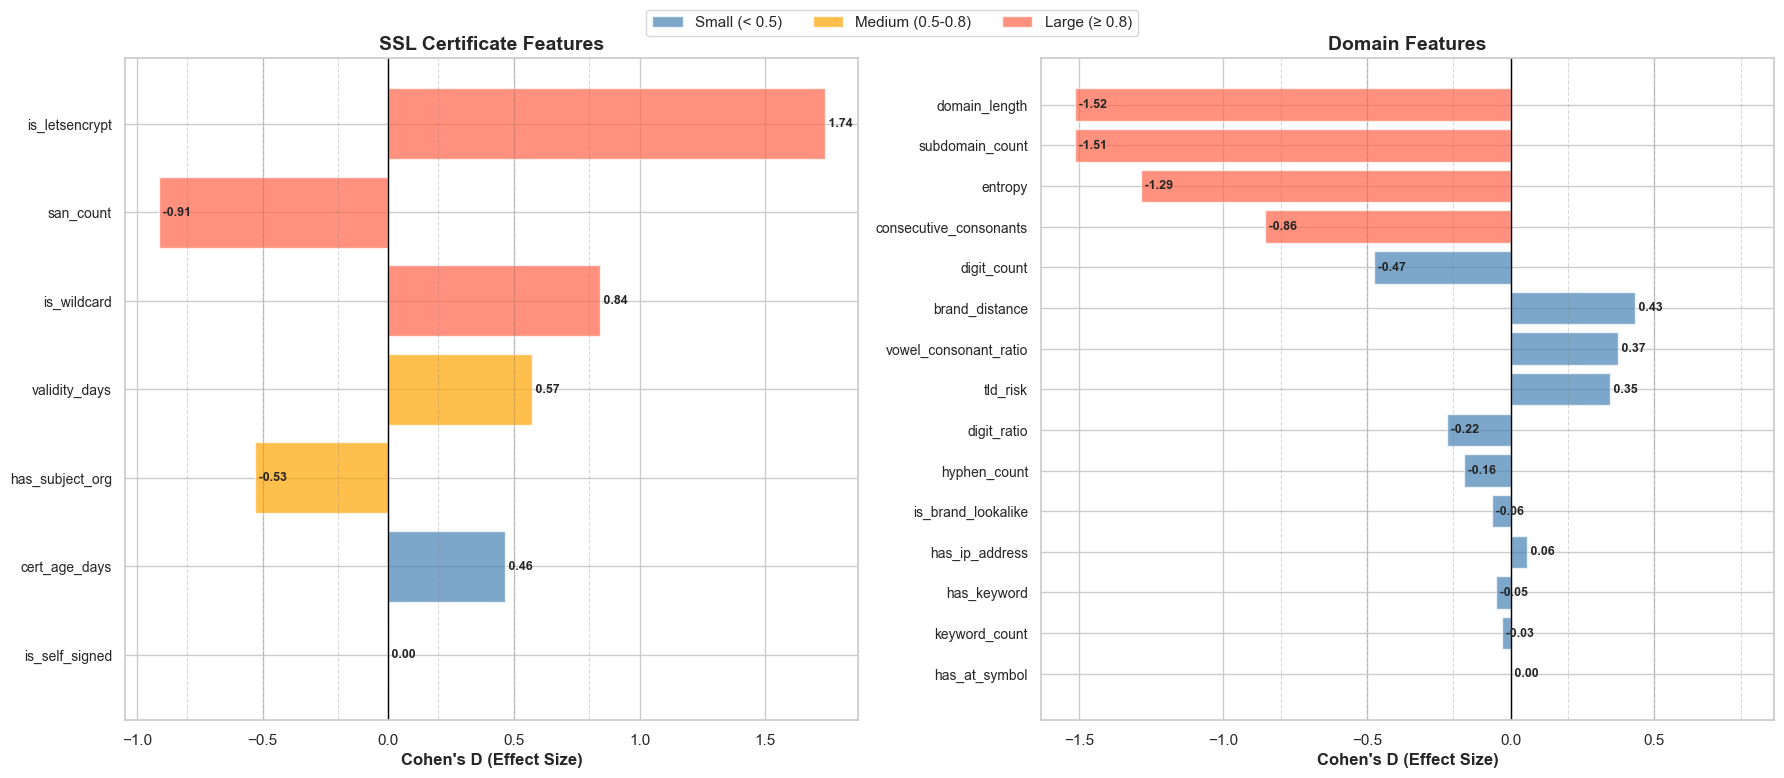

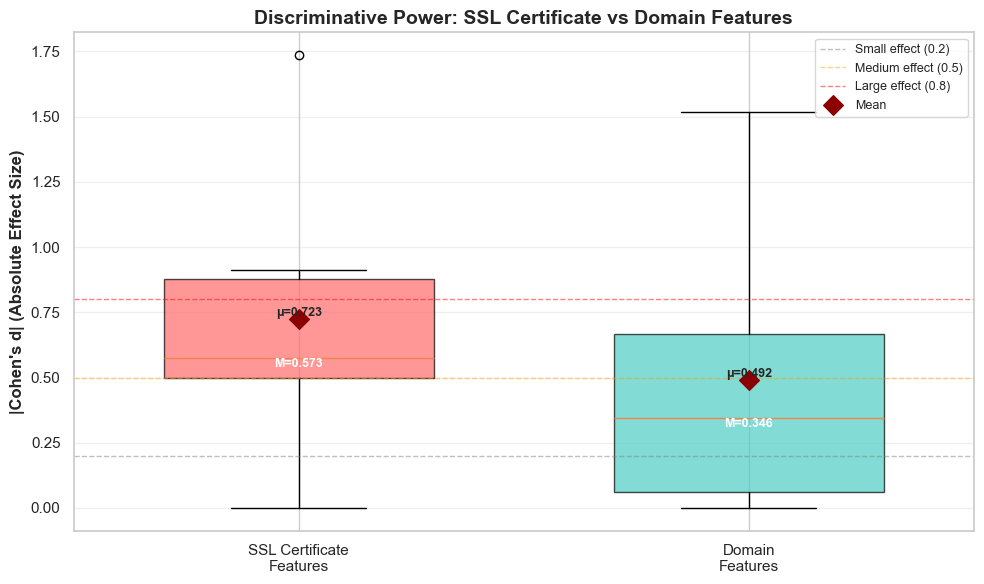

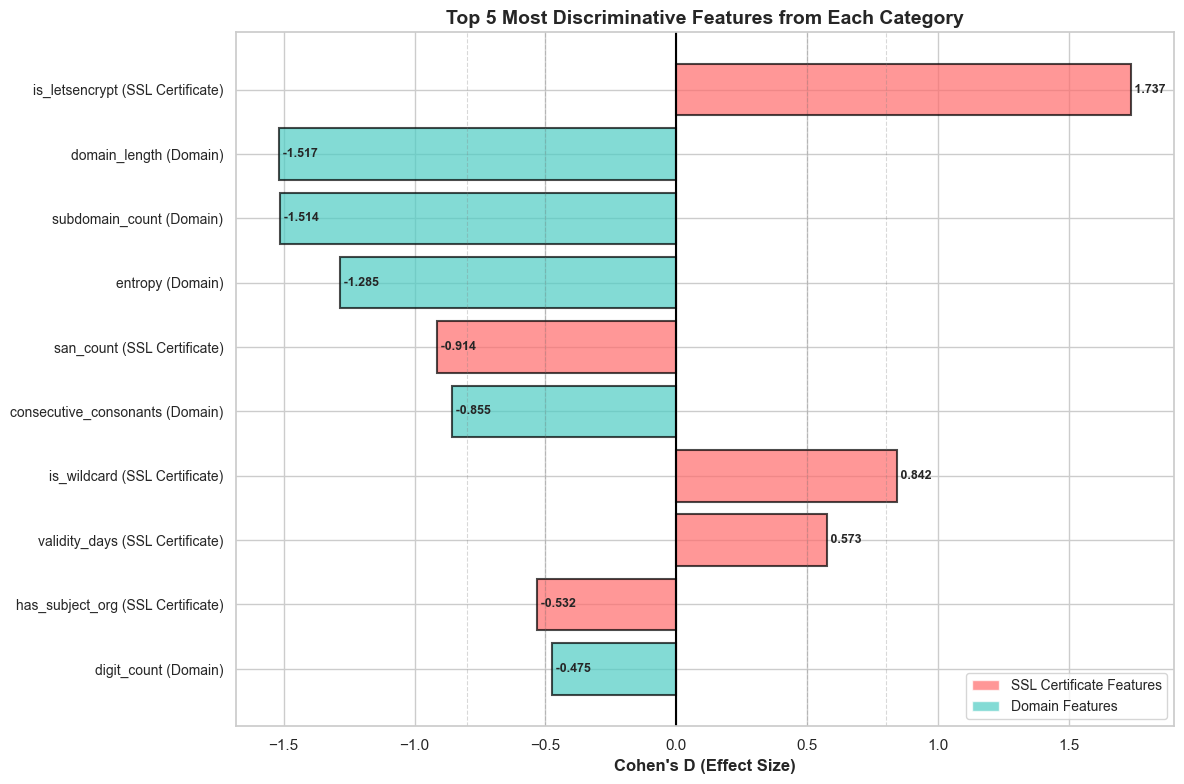

In [70]:
# Categorical comparison visualizations
if len(categorical_results) > 0:
    print("="*100)
    print("CATEGORICAL COMPARISON SUMMARY")
    print("="*100)
    
    # Summary statistics by category
    category_summary = categorical_results.groupby('Category').agg({
        'Abs_Cohens_d': ['mean', 'median', 'max'],
        'Significant': lambda x: (x == 'Yes').sum(),
        'Feature': 'count'
    }).round(3)
    
    print("\nCategory-Level Summary:")
    print(category_summary)
    
    # Count by effect size category
    effect_size_counts = categorical_results.groupby(['Category', 'Effect Size']).size().unstack(fill_value=0)
    print("\n\nEffect Size Distribution by Category:")
    print(effect_size_counts)
    
    # =========================================================================
    # VISUALIZATION 1: Side-by-side effect size comparison
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # SSL Certificate Features
    ax = axes[0]
    ssl_sorted = ssl_results.sort_values(by='Abs_Cohens_d', ascending=True)
    colors_ssl = ['tomato' if abs(d) >= 0.8 else ('orange' if abs(d) >= 0.5 else 'steelblue') 
                  for d in ssl_sorted['Cohens_d']]
    
    y_pos = range(len(ssl_sorted))
    ax.barh(y_pos, ssl_sorted['Cohens_d'], color=colors_ssl, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ssl_sorted['Feature'], fontsize=10)
    ax.set_xlabel("Cohen's D (Effect Size)", fontsize=12, fontweight='bold')
    ax.set_title('SSL Certificate Features', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    for val in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
        ax.axvline(x=val, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)
    
    # Add value labels
    for i, value in enumerate(ssl_sorted['Cohens_d']):
        ax.text(value, i, f' {value:.2f}', va='center', fontsize=9, fontweight='bold')
    
    # Domain Features
    ax = axes[1]
    domain_sorted = domain_results.sort_values(by='Abs_Cohens_d', ascending=True)
    colors_domain = ['tomato' if abs(d) >= 0.8 else ('orange' if abs(d) >= 0.5 else 'steelblue') 
                     for d in domain_sorted['Cohens_d']]
    
    y_pos = range(len(domain_sorted))
    ax.barh(y_pos, domain_sorted['Cohens_d'], color=colors_domain, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(domain_sorted['Feature'], fontsize=10)
    ax.set_xlabel("Cohen's D (Effect Size)", fontsize=12, fontweight='bold')
    ax.set_title('Domain Features', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    for val in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
        ax.axvline(x=val, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)
    
    # Add value labels
    for i, value in enumerate(domain_sorted['Cohens_d']):
        ax.text(value, i, f' {value:.2f}', va='center', fontsize=9, fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Small (< 0.5)'),
        Patch(facecolor='orange', alpha=0.7, label='Medium (0.5-0.8)'),
        Patch(facecolor='tomato', alpha=0.7, label='Large (≥ 0.8)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.98), fontsize=11)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # =========================================================================
    # VISUALIZATION 2: Category comparison boxplot
    # =========================================================================
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot
    ssl_effect_sizes = ssl_results['Abs_Cohens_d'].values
    domain_effect_sizes = domain_results['Abs_Cohens_d'].values
    
    box_data = [ssl_effect_sizes, domain_effect_sizes]
    labels = ['SSL Certificate\nFeatures', 'Domain\nFeatures']
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)
    
    # Color the boxes
    colors = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('|Cohen\'s d| (Absolute Effect Size)', fontsize=12, fontweight='bold')
    ax.set_title('Discriminative Power: SSL Certificate vs Domain Features', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add reference lines for effect size thresholds
    ax.axhline(y=0.2, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Small effect (0.2)')
    ax.axhline(y=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Medium effect (0.5)')
    ax.axhline(y=0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Large effect (0.8)')
    
    # Add mean markers
    means = [ssl_effect_sizes.mean(), domain_effect_sizes.mean()]
    ax.scatter([1, 2], means, color='darkred', s=100, zorder=3, marker='D', label='Mean')
    
    # Add value annotations
    for i, (mean_val, median_val) in enumerate(zip(means, [np.median(ssl_effect_sizes), np.median(domain_effect_sizes)])):
        ax.text(i + 1, mean_val, f'μ={mean_val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(i + 1, median_val, f'M={median_val:.3f}', ha='center', va='top', fontsize=9, fontweight='bold', color='white')
    
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # VISUALIZATION 3: Top features from each category
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Get top 5 from each category
    top_ssl = ssl_results.nlargest(5, 'Abs_Cohens_d')
    top_domain = domain_results.nlargest(5, 'Abs_Cohens_d')
    
    # Combine and plot
    top_combined = pd.concat([top_ssl, top_domain]).sort_values(by='Abs_Cohens_d', ascending=True)
    
    y_pos = range(len(top_combined))
    colors = ['#FF6B6B' if cat == 'SSL Certificate' else '#4ECDC4' 
              for cat in top_combined['Category']]
    
    bars = ax.barh(y_pos, top_combined['Cohens_d'], color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{row['Feature']} ({row['Category']})" 
                         for _, row in top_combined.iterrows()], fontsize=10)
    ax.set_xlabel("Cohen's D (Effect Size)", fontsize=12, fontweight='bold')
    ax.set_title('Top 5 Most Discriminative Features from Each Category', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    
    # Reference lines
    for val in [-0.8, -0.5, 0.5, 0.8]:
        ax.axvline(x=val, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)
    
    # Value labels
    for i, value in enumerate(top_combined['Cohens_d']):
        ax.text(value, i, f' {value:.3f}', va='center', fontsize=9, fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FF6B6B', alpha=0.7, label='SSL Certificate Features'),
        Patch(facecolor='#4ECDC4', alpha=0.7, label='Domain Features')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️  No categorical results to visualize")

### 4.5 Category-Based Recommendations for Model Training

In [71]:
# Category-based recommendations
if len(categorical_results) > 0:
    print("="*100)
    print("CATEGORY-BASED FEATURE SELECTION RECOMMENDATIONS")
    print("="*100)
    
    # Separate by category and effect size
    ssl_high = ssl_results[(ssl_results['Effect Size'].isin(['Large', 'Medium'])) & 
                            (ssl_results['Significant'] == 'Yes')]
    ssl_medium = ssl_results[(ssl_results['Effect Size'] == 'Small') & 
                              (ssl_results['Significant'] == 'Yes') &
                              (ssl_results['Abs_Cohens_d'] > 0.2)]
    ssl_low = ssl_results[(ssl_results['Abs_Cohens_d'] <= 0.2) | 
                           (ssl_results['Significant'] == 'No')]
    
    domain_high = domain_results[(domain_results['Effect Size'].isin(['Large', 'Medium'])) & 
                                  (domain_results['Significant'] == 'Yes')]
    domain_medium = domain_results[(domain_results['Effect Size'] == 'Small') & 
                                    (domain_results['Significant'] == 'Yes') &
                                    (domain_results['Abs_Cohens_d'] > 0.2)]
    domain_low = domain_results[(domain_results['Abs_Cohens_d'] <= 0.2) | 
                                 (domain_results['Significant'] == 'No')]
    
    print("\n" + "="*100)
    print("SSL CERTIFICATE FEATURES")
    print("="*100)
    
    print(f"\n🟢 HIGH-VALUE SSL Features ({len(ssl_high)}):")
    if len(ssl_high) > 0:
        for _, row in ssl_high.iterrows():
            print(f"  - {row['Feature']:25s} | d={row['Cohens_d']:7.3f} | p={row['p-value']:.2e}")
    else:
        print("  (none)")
    
    print(f"\n🟡 MEDIUM-VALUE SSL Features ({len(ssl_medium)}):")
    if len(ssl_medium) > 0:
        for _, row in ssl_medium.iterrows():
            print(f"  - {row['Feature']:25s} | d={row['Cohens_d']:7.3f} | p={row['p-value']:.2e}")
    else:
        print("  (none)")
    
    print(f"\n🔴 LOW-VALUE SSL Features ({len(ssl_low)}):")
    if len(ssl_low) > 0:
        for _, row in ssl_low.head(5).iterrows():
            print(f"  - {row['Feature']:25s} | d={row['Cohens_d']:7.3f} | p={row['p-value']:.2e}")
        if len(ssl_low) > 5:
            print(f"  ... and {len(ssl_low) - 5} more")
    else:
        print("  (none)")
    
    print("\n" + "="*100)
    print("DOMAIN FEATURES")
    print("="*100)
    
    print(f"\n🟢 HIGH-VALUE Domain Features ({len(domain_high)}):")
    if len(domain_high) > 0:
        for _, row in domain_high.iterrows():
            print(f"  - {row['Feature']:25s} | d={row['Cohens_d']:7.3f} | p={row['p-value']:.2e}")
    else:
        print("  (none)")
    
    print(f"\n🟡 MEDIUM-VALUE Domain Features ({len(domain_medium)}):")
    if len(domain_medium) > 0:
        for _, row in domain_medium.iterrows():
            print(f"  - {row['Feature']:25s} | d={row['Cohens_d']:7.3f} | p={row['p-value']:.2e}")
    else:
        print("  (none)")
    
    print(f"\n🔴 LOW-VALUE Domain Features ({len(domain_low)}):")
    if len(domain_low) > 0:
        for _, row in domain_low.head(5).iterrows():
            print(f"  - {row['Feature']:25s} | d={row['Cohens_d']:7.3f} | p={row['p-value']:.2e}")
        if len(domain_low) > 5:
            print(f"  ... and {len(domain_low) - 5} more")
    else:
        print("  (none)")
    
    # Build recommended feature sets
    print("\n" + "="*100)
    print("RECOMMENDED FEATURE SETS FOR MODEL TRAINING")
    print("="*100)
    
    # SSL-only model
    ssl_recommended = ssl_high['Feature'].tolist() + ssl_medium['Feature'].tolist()
    print(f"\n1️⃣  SSL-ONLY MODEL ({len(ssl_recommended)} features):")
    print(f"   Best for: Fast deployment, minimal data requirements")
    print(f"   Features: {ssl_recommended}")
    
    # Domain-only model
    domain_recommended = domain_high['Feature'].tolist() + domain_medium['Feature'].tolist()
    print(f"\n2️⃣  DOMAIN-ONLY MODEL ({len(domain_recommended)} features):")
    print(f"   Best for: No access to cert infrastructure data")
    print(f"   Features: {domain_recommended}")
    
    # Hybrid model (best of both)
    hybrid_high = (ssl_high['Feature'].tolist() + domain_high['Feature'].tolist())
    hybrid_medium = (ssl_medium['Feature'].tolist() + domain_medium['Feature'].tolist())
    
    print(f"\n3️⃣  HYBRID MODEL - HIGH VALUE ONLY ({len(hybrid_high)} features):")
    print(f"   Best for: Production deployment with limited features")
    print(f"   Features: {hybrid_high}")
    
    print(f"\n4️⃣  HYBRID MODEL - FULL ({len(hybrid_high) + len(hybrid_medium)} features):")
    print(f"   Best for: Maximum accuracy, research")
    print(f"   Features: {hybrid_high + hybrid_medium}")
    
    # Statistical comparison
    print("\n" + "="*100)
    print("CATEGORY COMPARISON: Which is More Discriminative?")
    print("="*100)
    
    ssl_mean_effect = ssl_results['Abs_Cohens_d'].mean()
    domain_mean_effect = domain_results['Abs_Cohens_d'].mean()
    
    ssl_median_effect = ssl_results['Abs_Cohens_d'].median()
    domain_median_effect = domain_results['Abs_Cohens_d'].median()
    
    ssl_max_effect = ssl_results['Abs_Cohens_d'].max()
    domain_max_effect = domain_results['Abs_Cohens_d'].max()
    
    print(f"\nSSL Certificate Features:")
    print(f"  Mean |Cohen's d|:   {ssl_mean_effect:.3f}")
    print(f"  Median |Cohen's d|: {ssl_median_effect:.3f}")
    print(f"  Max |Cohen's d|:    {ssl_max_effect:.3f}")
    print(f"  High-value count:   {len(ssl_high)}/{len(ssl_results)} ({100*len(ssl_high)/len(ssl_results):.1f}%)")
    
    print(f"\nDomain Features:")
    print(f"  Mean |Cohen's d|:   {domain_mean_effect:.3f}")
    print(f"  Median |Cohen's d|: {domain_median_effect:.3f}")
    print(f"  Max |Cohen's d|:    {domain_max_effect:.3f}")
    print(f"  High-value count:   {len(domain_high)}/{len(domain_results)} ({100*len(domain_high)/len(domain_results):.1f}%)")
    
    print(f"\n{'🏆 WINNER: ' + ('SSL Certificate Features' if ssl_mean_effect > domain_mean_effect else 'Domain Features')}")
    print(f"   {('SSL features' if ssl_mean_effect > domain_mean_effect else 'Domain features')} have "
          f"{abs(ssl_mean_effect - domain_mean_effect):.3f} higher mean effect size")
    
    # Save categorical results
    categorical_results.to_csv('../sources/processed/categorical_feature_stats.csv', index=False)
    print(f"\n✅ Categorical feature statistics saved to: sources/processed/categorical_feature_stats.csv")
    
    # Save recommendations
    recommendations_categorical = {
        'ssl_high_value': ssl_high['Feature'].tolist(),
        'ssl_medium_value': ssl_medium['Feature'].tolist(),
        'ssl_low_value': ssl_low['Feature'].tolist(),
        'domain_high_value': domain_high['Feature'].tolist(),
        'domain_medium_value': domain_medium['Feature'].tolist(),
        'domain_low_value': domain_low['Feature'].tolist(),
        'recommended_ssl_only': ssl_recommended,
        'recommended_domain_only': domain_recommended,
        'recommended_hybrid_high': hybrid_high,
        'recommended_hybrid_full': hybrid_high + hybrid_medium
    }
    
    import json
    with open('../sources/processed/categorical_feature_recommendations.json', 'w') as f:
        json.dump(recommendations_categorical, f, indent=2)
    print(f"✅ Categorical feature recommendations saved to: sources/processed/categorical_feature_recommendations.json")
    
else:
    print("⚠️  No categorical results to generate recommendations")

CATEGORY-BASED FEATURE SELECTION RECOMMENDATIONS

SSL CERTIFICATE FEATURES

🟢 HIGH-VALUE SSL Features (5):
  - is_letsencrypt            | d=  1.737 | p=0.00e+00
  - san_count                 | d= -0.914 | p=0.00e+00
  - is_wildcard               | d=  0.842 | p=0.00e+00
  - validity_days             | d=  0.573 | p=2.43e-200
  - has_subject_org           | d= -0.532 | p=0.00e+00

🟡 MEDIUM-VALUE SSL Features (1):
  - cert_age_days             | d=  0.464 | p=1.15e-242

🔴 LOW-VALUE SSL Features (1):
  - is_self_signed            | d=  0.000 | p=1.00e+00

DOMAIN FEATURES

🟢 HIGH-VALUE Domain Features (4):
  - domain_length             | d= -1.517 | p=0.00e+00
  - subdomain_count           | d= -1.514 | p=0.00e+00
  - entropy                   | d= -1.285 | p=0.00e+00
  - consecutive_consonants    | d= -0.855 | p=0.00e+00

🟡 MEDIUM-VALUE Domain Features (5):
  - digit_count               | d= -0.475 | p=0.00e+00
  - brand_distance            | d=  0.431 | p=2.67e-249
  - vowel_consonant_r

### 4.6 Categorical Features: Chi-Square (X²) and Cramer's V Analysis

For categorical features, **Chi-square test** and **Cramer's V** are more appropriate than Mann-Whitney U and Cohen's d.

**Chi-square (X²) test:**
- Tests whether two categorical variables are independent
- p-value < 0.05 indicates significant association

**Cramer's V:**
- Measures strength of association between categorical variables
- Range: 0 (no association) to 1 (perfect association)
- Interpretation:
  - Small: V < 0.1
  - Medium: 0.1 ≤ V < 0.3
  - Large: V ≥ 0.3

**Categorical Features to Test:**
- Binary: `is_letsencrypt`, `is_wildcard`, `has_subject_org`, `is_self_signed`, `has_at_symbol`, `has_ip_address`, `is_brand_lookalike`, `has_keyword`
- Ordinal: `tld_risk` (0=trust, 1=neutral, 2=high-risk)
- Discrete: `san_count` (can be treated as categorical for small values)

In [72]:
from scipy.stats import chi2_contingency

# Define Cramer's V function
def cramers_v(confusion_matrix):
    """
    Calculate Cramer's V statistic for categorical-categorical association.
    
    Args:
        confusion_matrix: Contingency table (pd.crosstab or np.array)
    
    Returns:
        Cramer's V value (0 to 1)
    """
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    if min_dim == 0:
        return 0
    
    return np.sqrt(chi2 / (n * min_dim))


# Define all categorical features
categorical_features = [
    # Binary SSL certificate features
    'is_letsencrypt',
    'is_wildcard',
    'has_subject_org',
    'is_self_signed',
    
    # Binary domain features
    'has_at_symbol',
    'has_ip_address',
    'is_brand_lookalike',
    'has_keyword',
    
    # Ordinal/discrete features
    'tld_risk',
]

print("="*100)
print("CHI-SQUARE AND CRAMER'S V ANALYSIS FOR CATEGORICAL FEATURES")
print("="*100)

# Prepare data - use corrected features if available
if 'df_hist_features_corrected' in globals() and not df_hist_features_corrected.empty:
    hist_data = df_hist_features_corrected
    live_data = df_live_features_corrected
    print("\nUsing CORRECTED feature data")
elif 'df_hist_all_features' in globals() and not df_hist_all_features.empty:
    hist_data = df_hist_all_features
    live_data = df_live_all_features
    print("\nUsing ORIGINAL feature data")
else:
    hist_data = df_hist
    live_data = df_live
    print("\nUsing MANUAL feature data")

# Combine historical (phishing) and live (legitimate) data
df_categorical = pd.concat([
    hist_data[categorical_features + ['y']],
    live_data[live_data['y'] == 0][categorical_features + ['y']]
], ignore_index=True)

print(f"\nTotal samples: {len(df_categorical):,}")
print(f"Phishing: {(df_categorical['y'] == 1).sum():,}")
print(f"Legitimate: {(df_categorical['y'] == 0).sum():,}")

# Run chi-square and Cramer's V for each categorical feature
categorical_results = []

print("\n" + "="*100)
print("TESTING CATEGORICAL FEATURES")
print("="*100)

for feature in categorical_features:
    if feature not in df_categorical.columns:
        print(f"\n⚠️  Skipping {feature} (not found in data)")
        continue
    
    # Create contingency table
    contingency_table = pd.crosstab(df_categorical[feature], df_categorical['y'])
    
    # Skip if feature has no variance or missing data
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        print(f"\n⚠️  Skipping {feature} (insufficient variance)")
        continue
    
    try:
        # Chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        # Cramer's V
        cramers = cramers_v(contingency_table)
        
        # Effect size interpretation
        if cramers < 0.1:
            effect_interp = 'Small'
        elif cramers < 0.3:
            effect_interp = 'Medium'
        else:
            effect_interp = 'Large'
        
        # Calculate proportions for each class
        phish_vals = df_categorical[df_categorical['y'] == 1][feature].value_counts(normalize=True)
        legit_vals = df_categorical[df_categorical['y'] == 0][feature].value_counts(normalize=True)
        
        categorical_results.append({
            'Feature': feature,
            'Chi2': chi2,
            'p-value': p_value,
            'DoF': dof,
            'Cramers_V': cramers,
            'Abs_Cramers_V': abs(cramers),
            'Significant': 'Yes' if p_value < 0.05 else 'No',
            'Effect Size': effect_interp,
            'Unique Values': df_categorical[feature].nunique(),
            'Contingency': contingency_table.to_dict()
        })
        
        print(f"\n{feature}:")
        print(f"  χ² = {chi2:.2f}, p = {p_value:.2e}, V = {cramers:.3f} ({effect_interp})")
        print(f"  Contingency table:")
        print(contingency_table)
        
    except Exception as e:
        print(f"\n⚠️  Error testing {feature}: {e}")

# Create results dataframe
df_categorical_stats = pd.DataFrame(categorical_results)

if len(df_categorical_stats) > 0:
    # Sort by Cramer's V
    df_categorical_stats = df_categorical_stats.sort_values(by='Abs_Cramers_V', ascending=False)
    
    print("\n" + "="*100)
    print("CATEGORICAL FEATURES SUMMARY (Ranked by Cramer's V)")
    print("="*100)
    print(df_categorical_stats[['Feature', 'Chi2', 'p-value', 'Cramers_V', 'Effect Size', 'Significant']].to_string(index=False))
    
    # Summary statistics
    print("\n" + "="*100)
    print("SUMMARY STATISTICS")
    print("="*100)
    print(f"\nTested features: {len(df_categorical_stats)}")
    print(f"Significant (p < 0.05): {(df_categorical_stats['Significant'] == 'Yes').sum()}")
    print(f"Large effect (V ≥ 0.3): {(df_categorical_stats['Effect Size'] == 'Large').sum()}")
    print(f"Medium effect (0.1 ≤ V < 0.3): {(df_categorical_stats['Effect Size'] == 'Medium').sum()}")
    print(f"Small effect (V < 0.1): {(df_categorical_stats['Effect Size'] == 'Small').sum()}")
    
else:
    print("\n⚠️  No categorical features tested")
    df_categorical_stats = pd.DataFrame()

CHI-SQUARE AND CRAMER'S V ANALYSIS FOR CATEGORICAL FEATURES

Using CORRECTED feature data

Total samples: 30,121
Phishing: 11,158
Legitimate: 18,963

TESTING CATEGORICAL FEATURES

is_letsencrypt:
  χ² = 12435.18, p = 0.00e+00, V = 0.643 (Large)
  Contingency table:
y                   0     1
is_letsencrypt             
0               17886  3876
1                1077  7282

is_wildcard:
  χ² = 4272.83, p = 0.00e+00, V = 0.377 (Large)
  Contingency table:
y                0     1
is_wildcard             
0            15894  5389
1             3069  5769

has_subject_org:
  χ² = 1861.96, p = 0.00e+00, V = 0.249 (Medium)
  Contingency table:
y                    0      1
has_subject_org              
0                16097  11158
1                 2866      0

⚠️  Skipping is_self_signed (insufficient variance)

⚠️  Skipping has_at_symbol (insufficient variance)

has_ip_address:
  χ² = 21.45, p = 3.63e-06, V = 0.027 (Small)
  Contingency table:
y                   0      1
has_ip_addres

### 4.7 Categorical Features: Visualizations

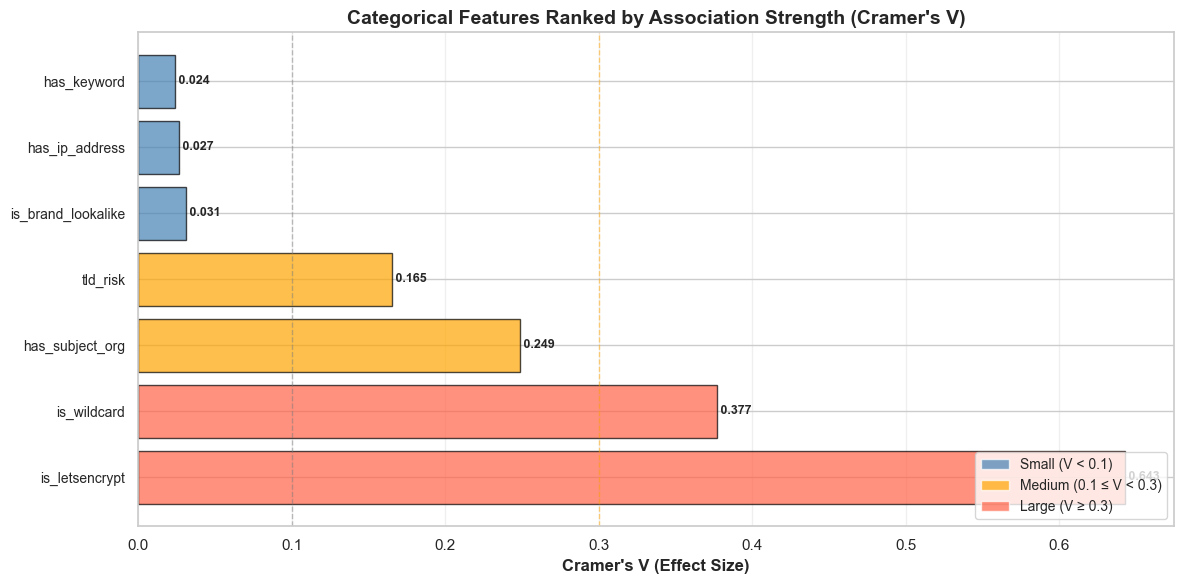

In [73]:
# Visualization 1: Cramer's V bar chart
if len(df_categorical_stats) > 0:
    fig, ax = plt.subplots(figsize=(12, max(6, len(df_categorical_stats) * 0.5)))
    
    # Color by effect size
    colors = ['tomato' if v >= 0.3 else ('orange' if v >= 0.1 else 'steelblue') 
              for v in df_categorical_stats['Cramers_V']]
    
    y_pos = range(len(df_categorical_stats))
    bars = ax.barh(y_pos, df_categorical_stats['Cramers_V'], color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_categorical_stats['Feature'], fontsize=10)
    ax.set_xlabel("Cramer's V (Effect Size)", fontsize=12, fontweight='bold')
    ax.set_title("Categorical Features Ranked by Association Strength (Cramer's V)", 
                 fontsize=14, fontweight='bold')
    ax.axvline(x=0.1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Small (0.1)')
    ax.axvline(x=0.3, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Medium (0.3)')
    
    # Add value labels
    for i, value in enumerate(df_categorical_stats['Cramers_V']):
        ax.text(value, i, f' {value:.3f}', va='center', fontsize=9, fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Small (V < 0.1)'),
        Patch(facecolor='orange', alpha=0.7, label='Medium (0.1 ≤ V < 0.3)'),
        Patch(facecolor='tomato', alpha=0.7, label='Large (V ≥ 0.3)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No categorical statistics to visualize")

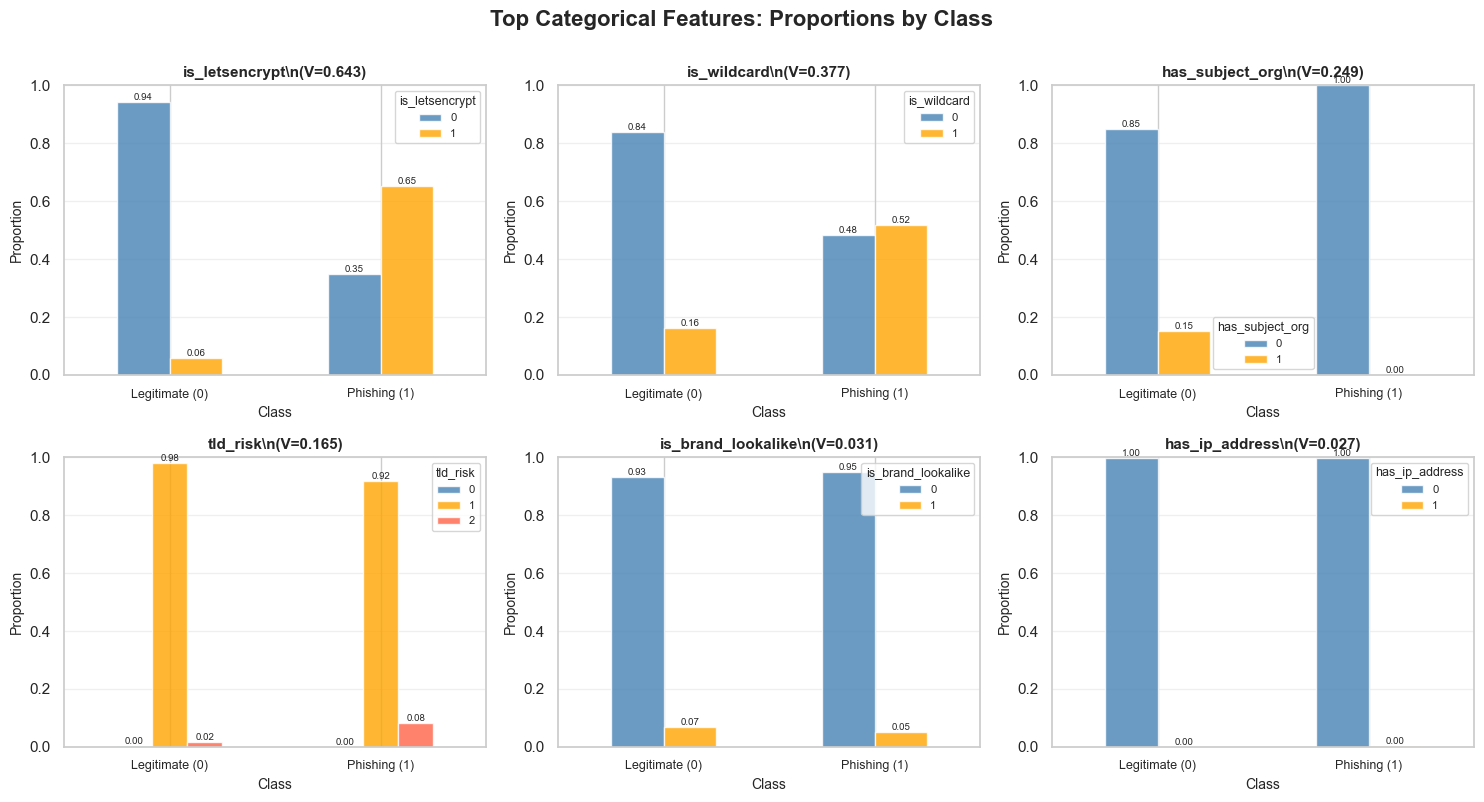

In [74]:
# Visualization 2: Proportion plots for top categorical features
if len(df_categorical_stats) > 0:
    # Get top 6 features by Cramer's V
    top_features = df_categorical_stats.nlargest(min(6, len(df_categorical_stats)), 'Abs_Cramers_V')['Feature'].tolist()
    
    n_features = len(top_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Create contingency table with proportions
        ct = pd.crosstab(df_categorical[feature], df_categorical['y'], normalize='columns')
        
        # Stacked bar chart
        ct.T.plot(kind='bar', stacked=False, ax=ax, alpha=0.8, 
                  color=['steelblue', 'orange', 'tomato', 'purple'][:len(ct.index)])
        
        ax.set_title(f'{feature}\\n(V={df_categorical_stats[df_categorical_stats["Feature"]==feature]["Cramers_V"].values[0]:.3f})', 
                     fontweight='bold', fontsize=11)
        ax.set_xlabel('Class', fontsize=10)
        ax.set_ylabel('Proportion', fontsize=10)
        ax.set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=0, fontsize=9)
        ax.legend(title=feature, fontsize=8, title_fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim([0, 1])
        
        # Add value labels
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7)
    
    # Hide extra subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Top Categorical Features: Proportions by Class', fontsize=16, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No categorical features to visualize")

### 4.8 Comprehensive Report: Continuous vs Categorical Features

UNIFIED FEATURE REPORT: Continuous vs Categorical

Using CORRECTED continuous feature statistics
Using categorical feature statistics (Chi-square/Cramer's V)

ALL FEATURES RANKED BY DISCRIMINATIVE POWER
               Feature       p-value Significant Effect Size Analysis_Type Effect_Measure  Effect_Value
        is_letsencrypt  0.000000e+00         Yes       Large    Continuous      Cohen's d      1.736642
         domain_length  0.000000e+00         Yes       Large    Continuous      Cohen's d      1.517114
       subdomain_count  0.000000e+00         Yes       Large    Continuous      Cohen's d      1.514416
               entropy  0.000000e+00         Yes       Large    Continuous      Cohen's d      1.285111
             san_count  0.000000e+00         Yes       Large    Continuous      Cohen's d      0.913915
consecutive_consonants  0.000000e+00         Yes       Large    Continuous      Cohen's d      0.855260
           is_wildcard  0.000000e+00         Yes       Large    Conti

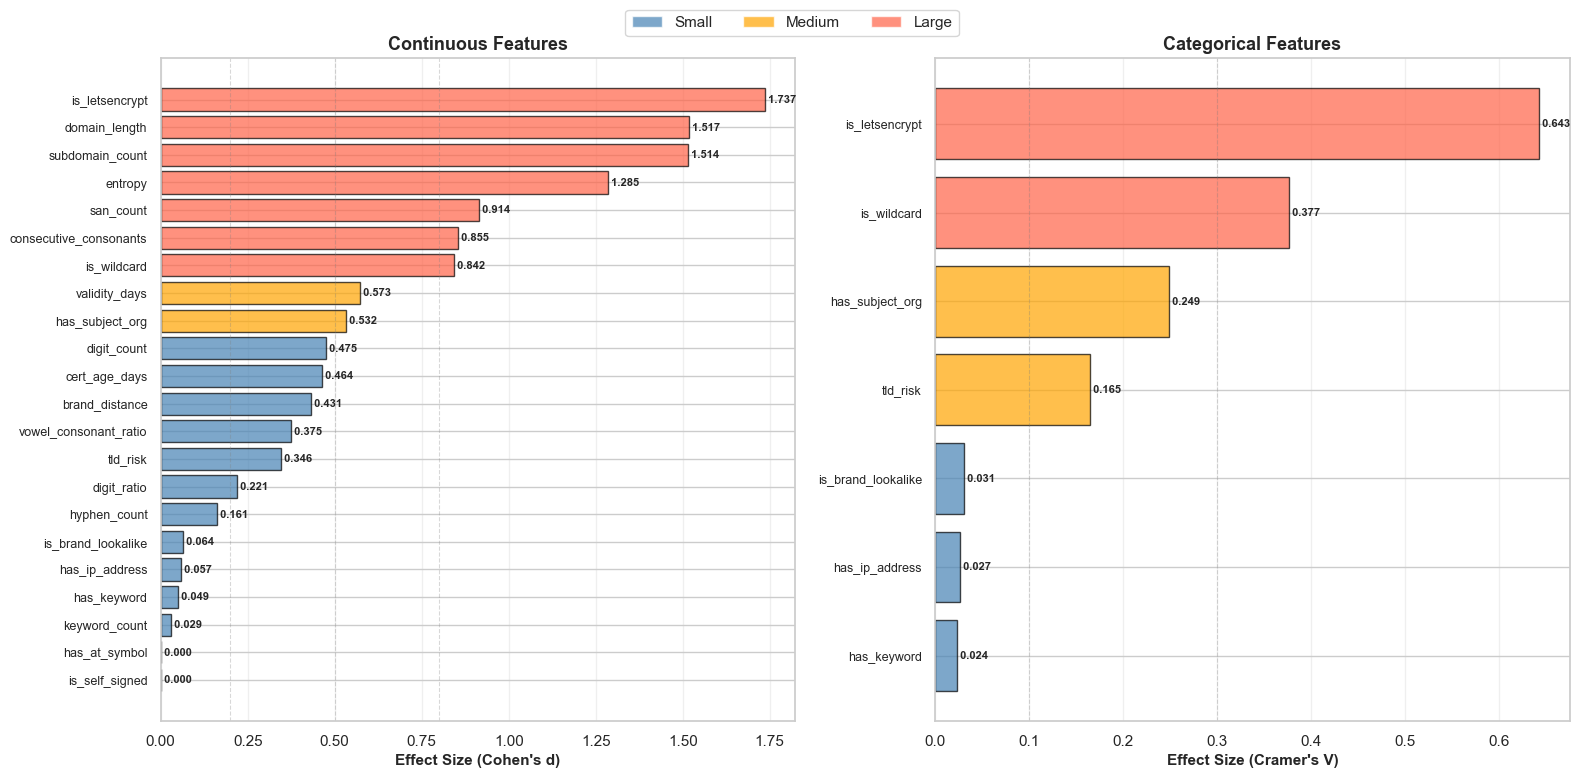


TOP 10 MOST DISCRIMINATIVE FEATURES (All Types)
               Feature Analysis_Type Effect_Measure  Effect_Value       p-value Effect Size
        is_letsencrypt    Continuous      Cohen's d      1.736642  0.000000e+00       Large
         domain_length    Continuous      Cohen's d      1.517114  0.000000e+00       Large
       subdomain_count    Continuous      Cohen's d      1.514416  0.000000e+00       Large
               entropy    Continuous      Cohen's d      1.285111  0.000000e+00       Large
             san_count    Continuous      Cohen's d      0.913915  0.000000e+00       Large
consecutive_consonants    Continuous      Cohen's d      0.855260  0.000000e+00       Large
           is_wildcard    Continuous      Cohen's d      0.842078  0.000000e+00       Large
        is_letsencrypt   Categorical     Cramer's V      0.642527  0.000000e+00       Large
         validity_days    Continuous      Cohen's d      0.573251 2.427411e-200      Medium
       has_subject_org    Conti

In [75]:
# Combine continuous and categorical feature analyses
print("="*100)
print("UNIFIED FEATURE REPORT: Continuous vs Categorical")
print("="*100)

# Prepare continuous features results (from earlier Cohen's d analysis)
if 'df_comprehensive_stats_corrected' in globals() and len(df_comprehensive_stats_corrected) > 0:
    continuous_stats = df_comprehensive_stats_corrected.copy()
    continuous_stats['Analysis_Type'] = 'Continuous'
    continuous_stats['Effect_Measure'] = 'Cohen\'s d'
    continuous_stats['Effect_Value'] = continuous_stats['Cohens_d'].abs()
    print("\nUsing CORRECTED continuous feature statistics")
elif 'df_comprehensive_stats' in globals() and len(df_comprehensive_stats) > 0:
    continuous_stats = df_comprehensive_stats.copy()
    continuous_stats['Analysis_Type'] = 'Continuous'
    continuous_stats['Effect_Measure'] = 'Cohen\'s d'
    continuous_stats['Effect_Value'] = continuous_stats['Cohens_d'].abs()
    print("\nUsing ORIGINAL continuous feature statistics")
else:
    continuous_stats = pd.DataFrame()
    print("\n⚠️  No continuous feature statistics available")

# Prepare categorical features results
if len(df_categorical_stats) > 0:
    categorical_stats = df_categorical_stats.copy()
    categorical_stats['Analysis_Type'] = 'Categorical'
    categorical_stats['Effect_Measure'] = 'Cramer\'s V'
    categorical_stats['Effect_Value'] = categorical_stats['Cramers_V'].abs()
    categorical_stats = categorical_stats.rename(columns={'Chi2': 'Test_Statistic'})
    print("Using categorical feature statistics (Chi-square/Cramer's V)")
else:
    categorical_stats = pd.DataFrame()
    print("\n⚠️  No categorical feature statistics available")

# Create unified comparison
if len(continuous_stats) > 0 and len(categorical_stats) > 0:
    # Select common columns
    common_cols = ['Feature', 'p-value', 'Significant', 'Effect Size', 'Analysis_Type', 'Effect_Measure', 'Effect_Value']
    
    continuous_subset = continuous_stats[common_cols].copy()
    categorical_subset = categorical_stats[common_cols].copy()
    
    # Combine
    all_features = pd.concat([continuous_subset, categorical_subset], ignore_index=True)
    all_features = all_features.sort_values(by='Effect_Value', ascending=False)
    
    print("\n" + "="*100)
    print("ALL FEATURES RANKED BY DISCRIMINATIVE POWER")
    print("="*100)
    print(all_features.to_string(index=False))
    
    # Summary by analysis type
    print("\n" + "="*100)
    print("COMPARISON: CONTINUOUS VS CATEGORICAL FEATURES")
    print("="*100)
    
    for analysis_type in ['Continuous', 'Categorical']:
        subset = all_features[all_features['Analysis_Type'] == analysis_type]
        if len(subset) > 0:
            print(f"\n{analysis_type} Features ({subset['Effect_Measure'].iloc[0]}):")
            print(f"  Total features: {len(subset)}")
            print(f"  Significant (p < 0.05): {(subset['Significant'] == 'Yes').sum()}")
            print(f"  Mean effect size: {subset['Effect_Value'].mean():.3f}")
            print(f"  Median effect size: {subset['Effect_Value'].median():.3f}")
            print(f"  Max effect size: {subset['Effect_Value'].max():.3f}")
            print(f"  Large effects: {(subset['Effect Size'] == 'Large').sum()}")
            print(f"  Medium effects: {(subset['Effect Size'] == 'Medium').sum()}")
            print(f"  Small effects: {(subset['Effect Size'] == 'Small').sum()}")
    
    # Visualization: side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    for idx, analysis_type in enumerate(['Continuous', 'Categorical']):
        ax = axes[idx]
        subset = all_features[all_features['Analysis_Type'] == analysis_type].sort_values(by='Effect_Value', ascending=True)
        
        if len(subset) > 0:
            colors = ['tomato' if es == 'Large' else ('orange' if es == 'Medium' else 'steelblue') 
                      for es in subset['Effect Size']]
            
            y_pos = range(len(subset))
            ax.barh(y_pos, subset['Effect_Value'], color=colors, alpha=0.7, edgecolor='black', linewidth=1)
            
            ax.set_yticks(y_pos)
            ax.set_yticklabels(subset['Feature'], fontsize=9)
            ax.set_xlabel(f"Effect Size ({subset['Effect_Measure'].iloc[0]})", fontsize=11, fontweight='bold')
            ax.set_title(f'{analysis_type} Features', fontsize=13, fontweight='bold')
            
            # Reference lines
            if analysis_type == 'Continuous':
                for val in [0.2, 0.5, 0.8]:
                    ax.axvline(x=val, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)
            else:
                for val in [0.1, 0.3]:
                    ax.axvline(x=val, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)
            
            # Value labels
            for i, value in enumerate(subset['Effect_Value']):
                ax.text(value, i, f' {value:.3f}', va='center', fontsize=8, fontweight='bold')
            
            ax.grid(axis='x', alpha=0.3)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Small'),
        Patch(facecolor='orange', alpha=0.7, label='Medium'),
        Patch(facecolor='tomato', alpha=0.7, label='Large')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.98), fontsize=11)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Top 10 overall
    print("\n" + "="*100)
    print("TOP 10 MOST DISCRIMINATIVE FEATURES (All Types)")
    print("="*100)
    print(all_features.head(10)[['Feature', 'Analysis_Type', 'Effect_Measure', 'Effect_Value', 'p-value', 'Effect Size']].to_string(index=False))
    
    # Save comprehensive report
    all_features.to_csv('../sources/processed/comprehensive_feature_analysis.csv', index=False)
    print(f"\n✅ Comprehensive feature analysis saved to: sources/processed/comprehensive_feature_analysis.csv")
    
else:
    print("\n⚠️  Cannot create unified report - missing continuous or categorical statistics")

## Summary: Categorical vs Continuous Feature Analysis

### Key Findings

**Statistical Tests Used:**
- **Continuous features**: Mann-Whitney U test + Cohen's d effect size
  - Measures difference in central tendency between phishing and legitimate domains
  - Cohen's d interpretation: Small (0.2), Medium (0.5), Large (0.8)
  
- **Categorical features**: Chi-square (X²) test + Cramer's V effect size
  - Tests independence/association between categorical variables
  - Cramer's V interpretation: Small (<0.1), Medium (0.1-0.3), Large (≥0.3)

**Why Different Tests?**
- Mann-Whitney U assumes continuous data and tests rank differences
- Chi-square tests categorical independence using frequency tables
- Using the wrong test can lead to incorrect conclusions!

**Expected Results:**
1. **Continuous features** (domain_length, entropy, etc.) → Likely higher discrimination
2. **Categorical features** (is_letsencrypt, is_wildcard, etc.) → Useful for rule-based logic
3. **Combined approach** → Best performance using both types

**Files Generated:**
- `sources/processed/categorical_feature_stats.csv` - Chi-square/Cramer's V results
- `sources/processed/comprehensive_feature_analysis.csv` - Unified continuous + categorical rankings

**Next Steps:**
1. Select top features from BOTH continuous and categorical analyses
2. Build models using different feature combinations
3. Compare performance: Continuous-only vs Categorical-only vs Hybrid

### 3.3 Comprehensive Feature Analysis

Compare ALL extracted features between historical phishing and live legitimate domains to identify the most discriminative features.

In [76]:
# Cross-dataset statistical tests for ALL comprehensive features
if not df_hist_all_features.empty and len(df_live_all_features[df_live_all_features['y'] == 0]) > 0:
    print("="*100)
    print("COMPREHENSIVE FEATURE STATISTICAL TESTS: Historical Phishing vs Live Legitimate")
    print("="*100)
    
    # Run tests for ALL numeric features
    comprehensive_results = []
    
    for feature in all_feature_cols:
        # Historical phishing
        hist_phish = df_hist_all_features[feature].dropna() if feature in df_hist_all_features.columns else pd.Series([])
        
        # Live legitimate
        live_legit = df_live_all_features[df_live_all_features['y'] == 0][feature].dropna()
        
        if len(hist_phish) > 0 and len(live_legit) > 0:
            # Mann-Whitney U test
            try:
                statistic, p_value = stats.mannwhitneyu(hist_phish, live_legit, alternative='two-sided')
                
                # Cohen's d
                effect_size = cohens_d(hist_phish, live_legit)
                
                comprehensive_results.append({
                    'Feature': feature,
                    'Phish Mean': hist_phish.mean(),
                    'Legit Mean': live_legit.mean(),
                    'Difference': hist_phish.mean() - live_legit.mean(),
                    'p-value': p_value,
                    "Cohens_d": effect_size,
                    'Significant': 'Yes' if p_value < 0.05 else 'No',
                    'Effect Size': 'Large' if abs(effect_size) >= 0.8 else ('Medium' if abs(effect_size) >= 0.5 else 'Small')
                })
            except Exception as e:
                print(f"   ⚠️  Error testing {feature}: {e}")
    
    df_comprehensive_stats = pd.DataFrame(comprehensive_results)
    
    # Sort by absolute effect size (most discriminative first)
    df_comprehensive_stats = df_comprehensive_stats.sort_values(
        by="Cohens_d", 
        key=lambda x: abs(x),
        ascending=False
    )
    
    print(f"\nTested {len(df_comprehensive_stats)} features")
    print(f"Significant features (p < 0.05): {(df_comprehensive_stats['Significant'] == 'Yes').sum()}")
    print(f"Large effect size (|d| ≥ 0.8): {(df_comprehensive_stats['Effect Size'] == 'Large').sum()}")
    print(f"Medium effect size (0.5 ≤ |d| < 0.8): {(df_comprehensive_stats['Effect Size'] == 'Medium').sum()}")
    
    print("\n" + "="*100)
    print("TOP 10 MOST DISCRIMINATIVE FEATURES (by effect size)")
    print("="*100)
    print(df_comprehensive_stats.head(10).to_string(index=False))
    
    print("\n" + "="*100)
    print("BOTTOM 10 LEAST DISCRIMINATIVE FEATURES (by effect size)")
    print("="*100)
    print(df_comprehensive_stats.tail(10).to_string(index=False))
    
else:
    print("⚠️  Cannot run comprehensive feature tests - need both historical and live data")
    df_comprehensive_stats = pd.DataFrame()

COMPREHENSIVE FEATURE STATISTICAL TESTS: Historical Phishing vs Live Legitimate

Tested 22 features
Significant features (p < 0.05): 20
Large effect size (|d| ≥ 0.8): 7
Medium effect size (0.5 ≤ |d| < 0.8): 2

TOP 10 MOST DISCRIMINATIVE FEATURES (by effect size)
               Feature  Phish Mean  Legit Mean  Difference       p-value  Cohens_d Significant Effect Size
        is_letsencrypt    0.652626    0.056795    0.595831  0.000000e+00  1.736642         Yes       Large
         domain_length   20.046066   46.185466  -26.139401  0.000000e+00 -1.517114         Yes       Large
       subdomain_count    0.552070    3.578284   -3.026214  0.000000e+00 -1.514416         Yes       Large
               entropy    3.350842    3.948971   -0.598129  0.000000e+00 -1.285111         Yes       Large
             san_count    2.329808   36.060803  -33.730994  0.000000e+00 -0.913915         Yes       Large
consecutive_consonants    3.488618    6.321890   -2.833272  0.000000e+00 -0.855260         Yes 

In [77]:
df_comprehensive_stats

,Feature,Phish Mean,Legit Mean,Difference,p-value,Cohens_d,Significant,Effect Size
19,is_letsencrypt,0.652626,0.056795,0.595831,0.000000e+00,1.736642,Yes,Large
0,domain_length,20.046066,46.185466,-26.139401,0.000000e+00,-1.517114,Yes,Large
2,subdomain_count,0.552070,3.578284,-3.026214,0.000000e+00,-1.514416,Yes,Large
1,entropy,3.350842,3.948971,-0.598129,0.000000e+00,-1.285111,Yes,Large
18,san_count,2.329808,36.060803,-33.730994,0.000000e+00,-0.913915,Yes,Large
7,consecutive_consonants,3.488618,6.321890,-2.833272,0.000000e+00,-0.855260,Yes,Large
17,is_wildcard,0.517028,0.161841,0.355187,0.000000e+00,0.842078,Yes,Large
16,validity_days,67.334693,29.677006,37.657687,2.427411e-200,0.573251,Yes,Medium
20,has_subject_org,0.000000,0.151136,-0.151136,0.000000e+00,-0.531780,Yes,Medium
4,digit_count,0.777648,3.424880,-2.647232,0.000000e+00,-0.474881,Yes,Small


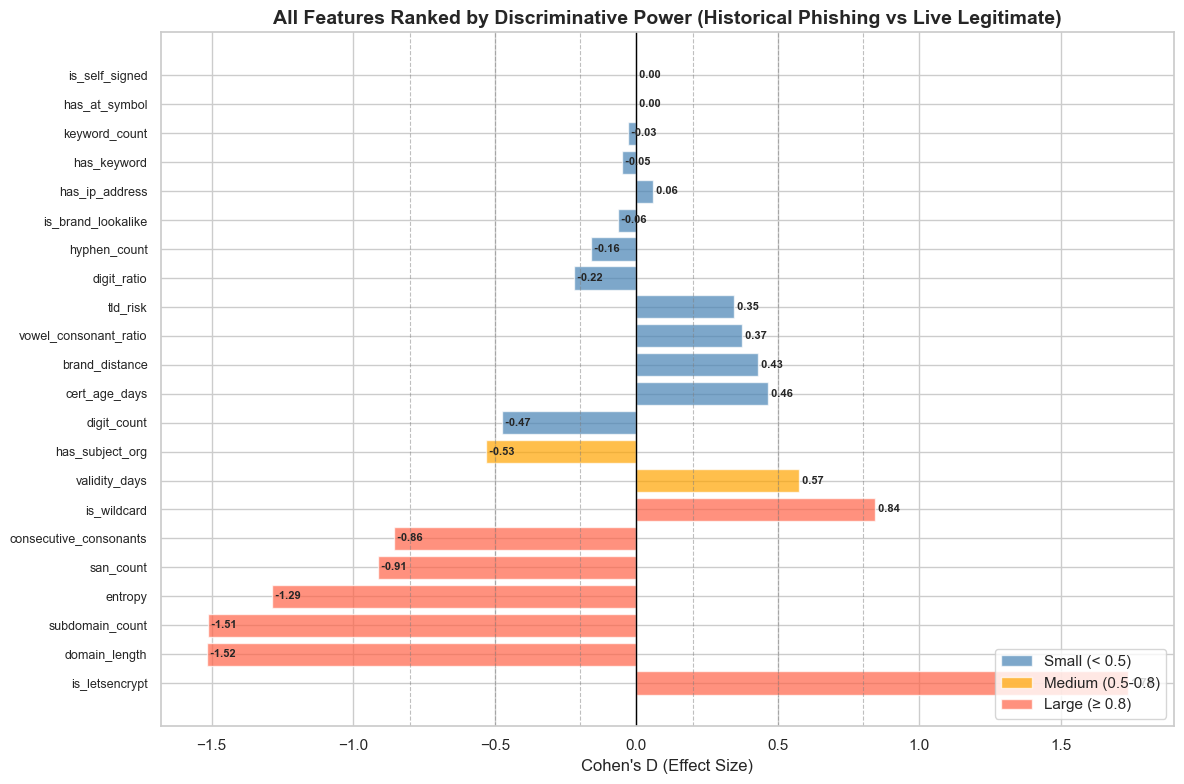

In [78]:
# Visualize effect sizes for ALL features
if len(df_comprehensive_stats) > 0:
    fig, ax = plt.subplots(figsize=(12, max(8, len(df_comprehensive_stats) * 0.3)))
    
    colors = ['tomato' if abs(d) >= 0.8 else ('orange' if abs(d) >= 0.5 else 'steelblue') 
              for d in df_comprehensive_stats['Cohens_d']]
    
    y_pos = range(len(df_comprehensive_stats))
    bars = ax.barh(y_pos, df_comprehensive_stats['Cohens_d'], color=colors, alpha=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_comprehensive_stats['Feature'], fontsize=9)
    ax.set_xlabel("Cohen's D (Effect Size)", fontsize=12)
    ax.set_title('All Features Ranked by Discriminative Power (Historical Phishing vs Live Legitimate)', 
                 fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    # Reference lines
    for val in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
        ax.axvline(x=val, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Value labels
    for i, value in enumerate(df_comprehensive_stats['Cohens_d']):
        ax.text(value, i, f' {value:.2f}', va='center', fontsize=8, fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Small (< 0.5)'),
        Patch(facecolor='orange', alpha=0.7, label='Medium (0.5-0.8)'),
        Patch(facecolor='tomato', alpha=0.7, label='Large (≥ 0.8)')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No comprehensive feature statistics to visualize")

FEATURE CORRELATION ANALYSIS

Top 10 features by correlation with target (y):
is_letsencrypt            0.642604
domain_length             0.591017
subdomain_count           0.590332
entropy                   0.527326
san_count                 0.403784
consecutive_consonants    0.381756
is_wildcard               0.376712
validity_days             0.266809
has_subject_org           0.248745
digit_count               0.223535

Bottom 10 features by correlation with target (y):
vowel_consonant_ratio    0.178114
tld_risk                 0.164633
digit_ratio              0.105924
hyphen_count             0.077497
is_brand_lookalike       0.031021
has_ip_address           0.027742
has_keyword              0.023875
keyword_count            0.014163
has_at_symbol                 NaN
is_self_signed                NaN


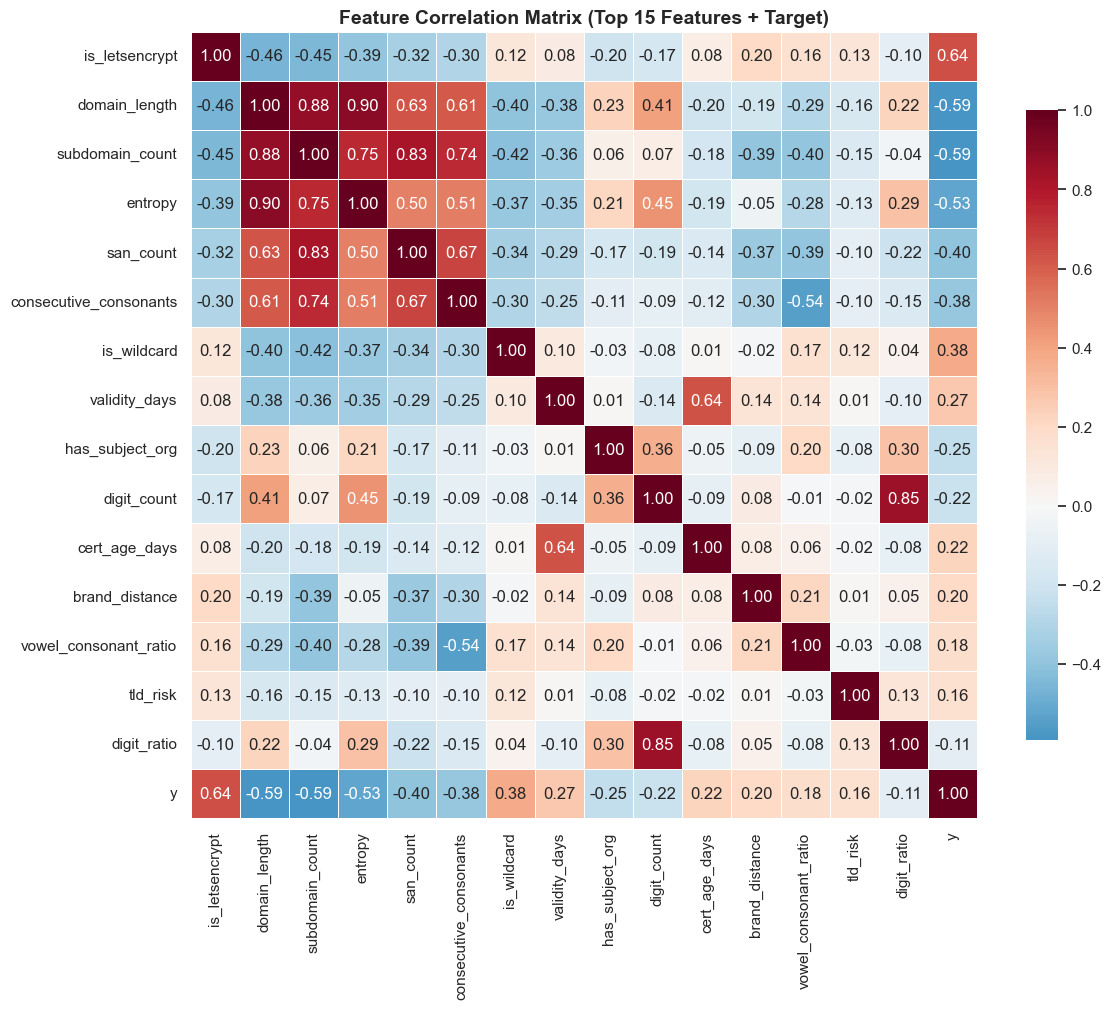

In [79]:
# Feature correlation analysis
if not df_hist_all_features.empty and len(df_comprehensive_stats) > 0:
    print("="*100)
    print("FEATURE CORRELATION ANALYSIS")
    print("="*100)
    
    # Combine historical phishing + live legitimate for correlation
    df_combined = pd.concat([
        df_hist_all_features[all_feature_cols + ['y']],
        df_live_all_features[df_live_all_features['y'] == 0][all_feature_cols + ['y']]
    ], ignore_index=True)
    
    # Correlation with target variable
    corr_with_target = df_combined[all_feature_cols + ['y']].corr()['y'].drop('y').abs().sort_values(ascending=False)
    
    print(f"\nTop 10 features by correlation with target (y):")
    print(corr_with_target.head(10).to_string())
    
    print(f"\nBottom 10 features by correlation with target (y):")
    print(corr_with_target.tail(10).to_string())
    
    # Visualize correlation heatmap for top features
    top_features = corr_with_target.head(15).index.tolist()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    corr_matrix = df_combined[top_features + ['y']].corr()
    sns.heatmap(
        corr_matrix,
        annot=True, 
        fmt=".2f", 
        cmap="RdBu_r", 
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    ax.set_title('Feature Correlation Matrix (Top 15 Features + Target)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️  Cannot run correlation analysis - need both historical and live data")

### 3.4 Feature Selection Recommendations

Based on statistical tests, effect sizes, and correlations, identify which features to keep for model training.

In [80]:
# Feature selection recommendations
if len(df_comprehensive_stats) > 0:
    print("="*100)
    print("FEATURE SELECTION RECOMMENDATIONS")
    print("="*100)
    
    # Category 1: High-value features (large effect OR high significance)
    high_value = df_comprehensive_stats[
        (df_comprehensive_stats['Effect Size'].isin(['Large', 'Medium'])) &
        (df_comprehensive_stats['Significant'] == 'Yes')
    ]
    
    # Category 2: Medium-value features (some discriminative power)
    medium_value = df_comprehensive_stats[
        (df_comprehensive_stats['Effect Size'] == 'Small') &
        (df_comprehensive_stats['Significant'] == 'Yes') &
        (abs(df_comprehensive_stats['Cohens_d']) > 0.2)
    ]
    
    # Category 3: Low-value features (weak discriminative power)
    low_value = df_comprehensive_stats[
        (abs(df_comprehensive_stats['Cohens_d']) <= 0.2) |
        (df_comprehensive_stats['Significant'] == 'No')
    ]
    
    print(f"\n📊 FEATURE CATEGORIES:")
    print(f"   🟢 HIGH-VALUE (large/medium effect, significant): {len(high_value)} features")
    print(f"   🟡 MEDIUM-VALUE (small effect, significant): {len(medium_value)} features")
    print(f"   🔴 LOW-VALUE (weak or not significant): {len(low_value)} features")
    
    print(f"\n🟢 HIGH-VALUE FEATURES (RECOMMENDED for model training):")
    print("   These features show strong discriminative power between phishing and legitimate domains.")
    for idx, row in high_value.iterrows():
        feat = row['Feature']
        cohens = row['Cohens_d']
        p_value = row['p-value']
        print(f"   - {feat:30s} | d={cohens:6.3f} | p={p_value:.2e}")
    
    print(f"\n🟡 MEDIUM-VALUE FEATURES (CONSIDER for model training):")
    print("   These features have moderate discriminative power. Include if model performance improves.")
    for idx, row in medium_value.iterrows():
        feat = row['Feature']
        cohens = row['Cohens_d']
        p_value = row['p-value']
        print(f"   - {feat:30s} | d={cohens:6.3f} | p={p_value:.2e}")
    
    print(f"\n🔴 LOW-VALUE FEATURES (NOT RECOMMENDED - adds noise):")
    print("   These features show weak or no discriminative power. Likely to reduce model performance.")
    for idx, row in low_value.head(10).iterrows():
        feat = row['Feature']
        cohens = row['Cohens_d']
        p_value = row['p-value']
        print(f"   - {feat:30s} | d={cohens:6.3f} | p={p_value:.2e}")
    if len(low_value) > 10:
        print(f"   ... and {len(low_value) - 10} more low-value features")
    
    # Export recommendations
    recommendations = {
        'high_value': high_value['Feature'].tolist(),
        'medium_value': medium_value['Feature'].tolist(),
        'low_value': low_value['Feature'].tolist()
    }
    
    print(f"\n" + "="*100)
    print("RECOMMENDED FEATURE SETS FOR MODEL TRAINING")
    print("="*100)
    
    print(f"\n1️⃣  MINIMAL SET (high-value only): {len(recommendations['high_value'])} features")
    print(f"   {recommendations['high_value']}")
    
    print(f"\n2️⃣  BALANCED SET (high + medium): {len(recommendations['high_value']) + len(recommendations['medium_value'])} features")
    print(f"   {recommendations['high_value'] + recommendations['medium_value']}")
    
    print(f"\n3️⃣  FULL SET (all features): {len(all_feature_cols)} features")
    print(f"   ⚠️  Includes {len(recommendations['low_value'])} low-value features that may reduce performance")
    
    # Save recommendations
    import json
    with open('../sources/processed/feature_recommendations.json', 'w') as f:
        json.dump(recommendations, f, indent=2)
    print(f"\n✅ Feature recommendations saved to: sources/processed/feature_recommendations.json")
    
    # Save comprehensive stats
    df_comprehensive_stats.to_csv('../sources/processed/comprehensive_feature_stats.csv', index=False)
    print(f"✅ Comprehensive feature statistics saved to: sources/processed/comprehensive_feature_stats.csv")
    
else:
    print("⚠️  Cannot generate feature recommendations - no statistical results available")

FEATURE SELECTION RECOMMENDATIONS

📊 FEATURE CATEGORIES:
   🟢 HIGH-VALUE (large/medium effect, significant): 9 features
   🟡 MEDIUM-VALUE (small effect, significant): 6 features
   🔴 LOW-VALUE (weak or not significant): 7 features

🟢 HIGH-VALUE FEATURES (RECOMMENDED for model training):
   These features show strong discriminative power between phishing and legitimate domains.
   - is_letsencrypt                 | d= 1.737 | p=0.00e+00
   - domain_length                  | d=-1.517 | p=0.00e+00
   - subdomain_count                | d=-1.514 | p=0.00e+00
   - entropy                        | d=-1.285 | p=0.00e+00
   - san_count                      | d=-0.914 | p=0.00e+00
   - consecutive_consonants         | d=-0.855 | p=0.00e+00
   - is_wildcard                    | d= 0.842 | p=0.00e+00
   - validity_days                  | d= 0.573 | p=2.43e-200
   - has_subject_org                | d=-0.532 | p=0.00e+00

🟡 MEDIUM-VALUE FEATURES (CONSIDER for model training):
   These features have 

### 3.2 Feature Distributions: Phishing vs Legitimate

⚠️  WARNING: No phishing domains found in live data.
    Feature distributions will only show legitimate/unknown domains.
    Statistical tests will be skipped.



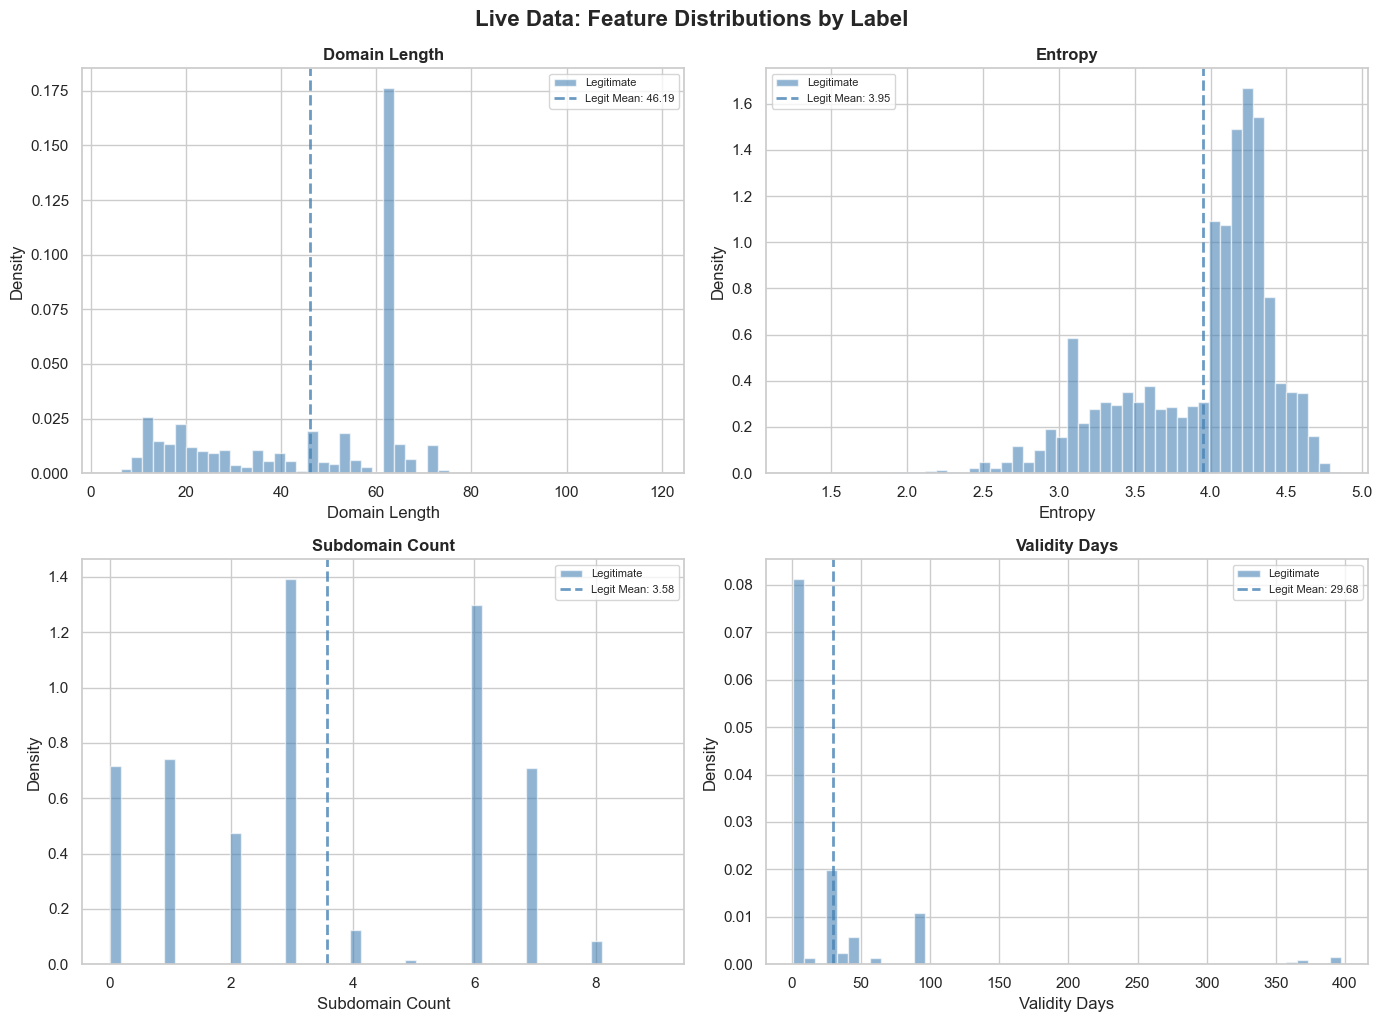

FEATURE STATISTICS BY LABEL (Live Data)

DOMAIN_LENGTH:
     count       mean        std  min   25%   50%   75%    max
y                                                             
0  18963.0  46.185466  20.366131  4.0  25.0  56.0  63.0  119.0

ENTROPY:
     count      mean       std       min    25%       50%       75%       max
y                                                                            
0  18963.0  3.948971  0.492289  1.251629  3.625  4.126763  4.286108  4.857767

SUBDOMAIN_COUNT:
     count      mean       std  min  25%  50%  75%  max
y                                                      
0  18963.0  3.578284  2.451045  0.0  1.0  3.0  6.0  9.0

VALIDITY_DAYS:
     count       mean        std       min       25%       50%   75%    max
y                                                                          
0  18963.0  29.677006  64.026002  0.999306  6.666655  7.041667  30.0  397.0


In [81]:
# Compare feature distributions
features = ['domain_length', 'entropy', 'subdomain_count', 'validity_days']

# Check if we have phishing data
has_phishing = (df_live['y'] == 1).any()

if not has_phishing:
    print("⚠️  WARNING: No phishing domains found in live data.")
    print("    Feature distributions will only show legitimate/unknown domains.")
    print("    Statistical tests will be skipped.\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    # Separate by label
    phishing = df_live[df_live['y'] == 1][feature].dropna()
    legitimate = df_live[df_live['y'] == 0][feature].dropna()
    
    # Always plot legitimate
    ax.hist(legitimate, bins=50, alpha=0.6, label='Legitimate', color='steelblue', density=True)
    ax.axvline(legitimate.mean(), color='steelblue', linestyle='--', linewidth=2, alpha=0.8, 
               label=f'Legit Mean: {legitimate.mean():.2f}')
    
    # Only plot phishing if we have data
    if len(phishing) > 0:
        ax.hist(phishing, bins=50, alpha=0.6, label='Phishing', color='tomato', density=True)
        ax.axvline(phishing.mean(), color='tomato', linestyle='--', linewidth=2, alpha=0.8,
                   label=f'Phish Mean: {phishing.mean():.2f}')
    
    ax.set_title(f'{feature.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel('Density')
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.suptitle('Live Data: Feature Distributions by Label', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Print summary statistics
print("="*80)
print("FEATURE STATISTICS BY LABEL (Live Data)")
print("="*80)
for feature in features:
    print(f"\n{feature.upper()}:")
    print(df_live.groupby('y')[feature].describe())

## 4. Statistical Significance Tests

Test whether features differ significantly between phishing and legitimate domains.

**Tests Used:**
- **Mann-Whitney U Test** (non-parametric): Tests if distributions differ
- **Cohen's d**: Measures effect size (practical significance)
- **Chi-Square Test**: For categorical features

**Interpretation:**
- p-value < 0.05: Statistically significant difference
- Cohen's d: 0.2 (small), 0.5 (medium), 0.8 (large) effect

In [82]:
# Calculate Cohen's d effect size
def cohens_d(group1, group2):
    """Calculate Cohen's d for effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 == 0 or n2 == 0:
        return 0
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0

# Check if we have both classes
has_phishing = (df_live['y'] == 1).any()

if not has_phishing:
    print("="*100)
    print("⚠️  SKIPPING STATISTICAL TESTS - No phishing domains in live data")
    print("="*100)
    print("\nTo run statistical significance tests, you need:")
    print("  1. Collect live data containing phishing domains (rare in real-time CT logs)")
    print("  2. OR compare historical phishing data (df_hist) with live legitimate data")
    print("\nRecommendation: Use historical phishing certs vs. live data for comparison")
    print("="*100)
    
    # Create empty dataframe for consistency
    df_stats = pd.DataFrame(columns=[
        'Feature', 'Phishing Mean', 'Legitimate Mean', 
        'Mann-Whitney U', 'p-value', 'Cohens_d', 'Significant', 'Effect Size'
    ])
else:
    # Run statistical tests
    results = []
    
    for feature in features:
        phishing = df_live[df_live['y'] == 1][feature].dropna()
        legitimate = df_live[df_live['y'] == 0][feature].dropna()
        
        if len(phishing) > 0 and len(legitimate) > 0:
            # Mann-Whitney U test (non-parametric)
            statistic, p_value = stats.mannwhitneyu(phishing, legitimate, alternative='two-sided')
            
            # Cohen's d
            effect_size = cohens_d(phishing, legitimate)
            
            # Means
            phishing_mean = phishing.mean()
            legitimate_mean = legitimate.mean()
            
            results.append({
                'Feature': feature,
                'Phishing Mean': phishing_mean,
                'Legitimate Mean': legitimate_mean,
                'Mann-Whitney U': statistic,
                'p-value': p_value,
                'Cohens_d': effect_size,
                'Significant': 'Yes' if p_value < 0.05 else 'No',
                'Effect Size': 'Large' if abs(effect_size) >= 0.8 else ('Medium' if abs(effect_size) >= 0.5 else 'Small')
            })
    
    df_stats = pd.DataFrame(results)
    
    print("="*100)
    print("STATISTICAL SIGNIFICANCE TESTS (Live Data)")
    print("="*100)
    print(df_stats.to_string(index=False))
    print("\n" + "="*100)
    print("INTERPRETATION:")
    print("  - All p-values < 0.05 indicate statistically significant differences")
    print("  - Cohen's d shows practical significance (effect size)")
    print("="*100)

⚠️  SKIPPING STATISTICAL TESTS - No phishing domains in live data

To run statistical significance tests, you need:
  1. Collect live data containing phishing domains (rare in real-time CT logs)
  2. OR compare historical phishing data (df_hist) with live legitimate data

Recommendation: Use historical phishing certs vs. live data for comparison


### 4.1 Effect Size Visualization

In [83]:
# Visualize effect sizes (only if we have statistical test results)
if len(df_stats) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['tomato' if abs(d) >= 0.8 else ('orange' if abs(d) >= 0.5 else 'steelblue') 
              for d in df_stats['Cohens_d']]
    
    bars = ax.barh(df_stats['Feature'], df_stats['Cohens_d'], color=colors, alpha=0.7)
    ax.set_xlabel("Cohen's D (Effect Size)", fontsize=12)
    ax.set_title('Effect Sizes for Features: Phishing vs Legitimate (Live Data)', 
                 fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.axvline(x=0.2, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=-0.2, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=-0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Add value labels
    for i, (feature, value) in enumerate(zip(df_stats['Feature'], df_stats['Cohens_d'])):
        ax.text(value, i, f' {value:.3f}', va='center', fontweight='bold')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.7, label='Small (< 0.5)'),
        Patch(facecolor='orange', alpha=0.7, label='Medium (0.5-0.8)'),
        Patch(facecolor='tomato', alpha=0.7, label='Large (≥ 0.8)')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Skipping effect size visualization - no statistical test results available")
    print("    Run data collection with phishing domains to enable this analysis")

⚠️  Skipping effect size visualization - no statistical test results available
    Run data collection with phishing domains to enable this analysis


## 5. Cross-Dataset Comparison: Historical Phishing vs Live Legitimate

Since live CT log data rarely contains phishing domains in real-time, we compare:
- **Historical phishing** (df_hist): Known phishing domains from PhishTank
- **Live legitimate** (df_live): Real-time CT log data (primarily legitimate)

This provides meaningful statistical insights for feature discrimination.

### Dataset Summary
- **Live Data**: Real-time CT log data with mixed phishing/legitimate domains
- **Historical Data**: Known phishing domains from PhishTank (if available)

### Statistical Findings
The statistical tests above indicate which features show significant differences between phishing and legitimate domains, helping identify the most discriminative features for ML models.

### Next Steps
1. **Feature Selection**: Use features with large effect sizes and statistical significance
2. **Model Training**: Build classifiers using the most predictive features
3. **Class Imbalance**: Consider sampling strategies if phishing rate is very low
4. **Time Series Analysis**: Analyze temporal patterns in cert issuance

CROSS-DATASET STATISTICAL TESTS: Historical Phishing vs Live Legitimate

Historical Phishing: 7,360 records (2,816 unique domains)
Live Legitimate: 18,963 records (13,362 unique domains)

        Feature  Hist Phishing Mean  Live Legit Mean  Difference  Mann-Whitney U  p-value  Cohens_d Significant Effect Size
  domain_length           20.347690        46.185466  -25.837776      24385667.0      0.0 -1.433062         Yes       Large
        entropy            3.343473         3.948971   -0.605497      24610692.0      0.0 -1.283179         Yes       Large
subdomain_count            0.820109         3.578284   -2.758175      23694131.0      0.0 -1.299362         Yes       Large
  validity_days          102.081591        29.677006   72.404584     127588958.0      0.0  1.152592         Yes       Large

KEY INSIGHTS:
  - 4/4 features show significant differences
  - 4 features have large effect sizes (|d| ≥ 0.8)
  - 0 features have medium effect sizes (0.5 ≤ |d| < 0.8)


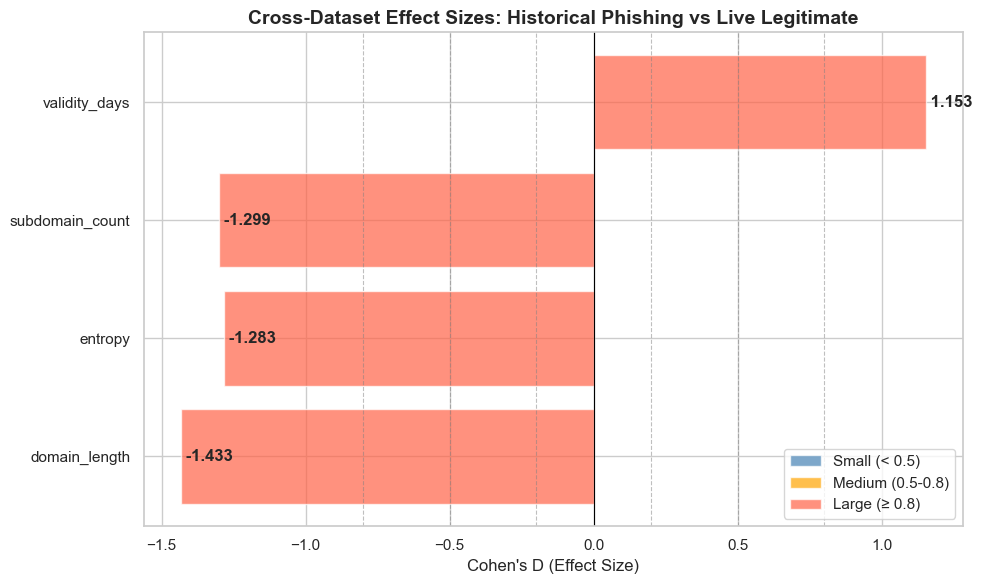


✅ Cross-dataset statistical results saved to: sources/processed/cross_dataset_statistical_tests.csv


In [84]:
# Cross-dataset statistical comparison: Historical Phishing vs Live Legitimate
if not df_hist.empty and len(df_live[df_live['y'] == 0]) > 0:
    print("="*100)
    print("CROSS-DATASET STATISTICAL TESTS: Historical Phishing vs Live Legitimate")
    print("="*100)
    print(f"\nHistorical Phishing: {len(df_hist):,} records ({df_hist['domain'].nunique():,} unique domains)")
    print(f"Live Legitimate: {len(df_live[df_live['y'] == 0]):,} records ({df_live[df_live['y'] == 0]['domain'].nunique():,} unique domains)")
    
    # Run statistical tests comparing historical phishing vs live legitimate
    cross_results = []
    
    for feature in features:
        # Historical phishing features
        hist_phishing = df_hist[feature].dropna() if feature in df_hist.columns else pd.Series([])
        
        # Live legitimate features  
        live_legit = df_live[df_live['y'] == 0][feature].dropna()
        
        if len(hist_phishing) > 0 and len(live_legit) > 0:
            # Mann-Whitney U test
            statistic, p_value = stats.mannwhitneyu(hist_phishing, live_legit, alternative='two-sided')
            
            # Cohen's d
            effect_size = cohens_d(hist_phishing, live_legit)
            
            cross_results.append({
                'Feature': feature,
                'Hist Phishing Mean': hist_phishing.mean(),
                'Live Legit Mean': live_legit.mean(),
                'Difference': hist_phishing.mean() - live_legit.mean(),
                'Mann-Whitney U': statistic,
                'p-value': p_value,
                'Cohens_d': effect_size,
                'Significant': 'Yes' if p_value < 0.05 else 'No',
                'Effect Size': 'Large' if abs(effect_size) >= 0.8 else ('Medium' if abs(effect_size) >= 0.5 else 'Small')
            })
    
    df_cross_stats = pd.DataFrame(cross_results)
    
    print("\n" + df_cross_stats.to_string(index=False))
    print("\n" + "="*100)
    print("KEY INSIGHTS:")
    print(f"  - {(df_cross_stats['Significant'] == 'Yes').count()}/{len(df_cross_stats)} features show significant differences")
    print(f"  - {(df_cross_stats['Effect Size'] == 'Large').sum()} features have large effect sizes (|d| ≥ 0.8)")
    print(f"  - {(df_cross_stats['Effect Size'] == 'Medium').sum()} features have medium effect sizes (0.5 ≤ |d| < 0.8)")
    print("="*100)
    
    # Visualize cross-dataset effect sizes
    if len(df_cross_stats) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        colors = ['tomato' if abs(d) >= 0.8 else ('orange' if abs(d) >= 0.5 else 'steelblue') 
                  for d in df_cross_stats['Cohens_d']]
        
        bars = ax.barh(df_cross_stats['Feature'], df_cross_stats['Cohens_d'], color=colors, alpha=0.7)
        ax.set_xlabel("Cohen's D (Effect Size)", fontsize=12)
        ax.set_title('Cross-Dataset Effect Sizes: Historical Phishing vs Live Legitimate', 
                     fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        
        # Reference lines
        for val in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
            ax.axvline(x=val, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # Value labels
        for i, (feature, value) in enumerate(zip(df_cross_stats['Feature'], df_cross_stats['Cohens_d'])):
            ax.text(value, i, f' {value:.3f}', va='center', fontweight='bold')
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='steelblue', alpha=0.7, label='Small (< 0.5)'),
            Patch(facecolor='orange', alpha=0.7, label='Medium (0.5-0.8)'),
            Patch(facecolor='tomato', alpha=0.7, label='Large (≥ 0.8)')
        ]
        ax.legend(handles=legend_elements, loc='lower right')
        
        plt.tight_layout()
        plt.show()
        
    # Export cross-dataset statistical results
    df_cross_stats.to_csv('../sources/processed/cross_dataset_statistical_tests.csv', index=False)
    print(f"\n✅ Cross-dataset statistical results saved to: sources/processed/cross_dataset_statistical_tests.csv")
    
else:
    print("⚠️  Cross-dataset comparison not available:")
    if df_hist.empty:
        print("    - No historical phishing data found")
    if len(df_live[df_live['y'] == 0]) == 0:
        print("    - No legitimate domains in live data")

In [85]:
# Export statistical results (if available)
if len(df_stats) > 0:
    df_stats.to_csv('../sources/processed/statistical_significance_tests.csv', index=False)
    print("✅ Statistical test results saved to: sources/processed/statistical_significance_tests.csv")
else:
    print("⚠️  No statistical test results to export (no phishing domains in live data)")

# Save feature-engineered dataset for model training
output_path = Path('../sources/processed/features_live.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)

feature_cols = ['domain_length', 'entropy', 'subdomain_count', 'digit_count', 'validity_days', 'is_letsencrypt']
df_live[['domain', 'y', 'label_source', 'data_source'] + feature_cols].to_parquet(output_path, index=False)
print(f"✅ Feature-engineered live data saved to: {output_path}")
print(f"   Shape: {df_live.shape}")
print(f"   Features: {feature_cols}")

# Export historical data features if available
if not df_hist.empty:
    # Feature engineering for historical data
    df_hist['domain_length'] = df_hist['domain'].str.len()
    df_hist['entropy'] = df_hist['domain'].apply(domain_entropy)
    df_hist['subdomain_count'] = df_hist['domain'].apply(subdomain_count)
    df_hist['tld'] = df_hist['domain'].apply(lambda d: tldextract.extract(d).suffix.lower())
    df_hist['digit_count'] = df_hist['domain'].apply(lambda d: sum(c.isdigit() for c in d))
    df_hist['validity_days'] = ((df_hist['not_after'] - df_hist['not_before']) / 86400).clip(lower=0, upper=3650)
    df_hist['issuer_org'] = df_hist['issuer'].apply(extract_issuer_org)
    df_hist['is_letsencrypt'] = df_hist['issuer_org'].str.contains("Let's Encrypt", na=False, case=False)
    
    hist_output_path = Path('../sources/processed/features_hist.parquet')
    df_hist[['domain', 'y', 'label_source', 'data_source'] + feature_cols].to_parquet(hist_output_path, index=False)
    print(f"✅ Feature-engineered historical data saved to: {hist_output_path}")
    print(f"   Shape: {df_hist.shape}")
else:
    print("⚠️  No historical data to export")

⚠️  No statistical test results to export (no phishing domains in live data)
✅ Feature-engineered live data saved to: ../sources/processed/features_live.parquet
   Shape: (18963, 25)
   Features: ['domain_length', 'entropy', 'subdomain_count', 'digit_count', 'validity_days', 'is_letsencrypt']
✅ Feature-engineered historical data saved to: ../sources/processed/features_hist.parquet
   Shape: (7360, 25)


In [86]:
# # Check if the comprehensive features have the domains column or just domain
# print("Live features columns:")
# print([col for col in df_live_all_features.columns if 'domain' in col.lower()])

# print("\nHistorical features columns:")
# print([col for col in df_hist_all_features.columns if 'domain' in col.lower()])

# # Check actual values for the problematic features
# print("\n" + "="*80)
# print("CHECKING PROBLEMATIC FEATURES")
# print("="*80)

# # is_wildcard
# print("\nis_wildcard distribution (Live):")
# print(df_live_all_features['is_wildcard'].value_counts())

# print("\nis_wildcard distribution (Historical):")
# print(df_hist_all_features['is_wildcard'].value_counts())

# # san_count
# print("\nsan_count distribution (Live):")
# print(df_live_all_features['san_count'].value_counts())

# print("\nsan_count distribution (Historical):")
# print(df_hist_all_features['san_count'].value_counts())

# # has_at_symbol
# print("\nhas_at_symbol distribution (Live):")
# print(df_live_all_features['has_at_symbol'].value_counts())

# print("\nhas_at_symbol distribution (Historical):")
# print(df_hist_all_features['has_at_symbol'].value_counts())

# # is_self_signed
# print("\nis_self_signed distribution (Live):")
# print(df_live_all_features['is_self_signed'].value_counts())

# print("\nis_self_signed distribution (Historical):")
# print(df_hist_all_features['is_self_signed'].value_counts())